The following code contains multiple sections that are the baseline for our NLP project. It is important to note that this notebook has been combined from seperate notesbooks as the different steps involve differnt versions of numpy. Therefore, certain code blocs are repeated such as loading the dataset, so that the code can be run in seperate sections.

0. Generation of the synthetic datasets with LLaMA
1. EDA
2. Feature Engineering
3. Classification Modelling



In [ ]:
!pip install numpy==1.24.4 --force-reinstall
!pip install gensim
!pip install pyLDAvis
!pip install vaderSentiment

In [ ]:
#import libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import spacy
import pyLDAvis
import pyLDAvis.gensim_models
import re
import torch
import time
import glob
import os

from google.colab import files
from matplotlib.colors import ListedColormap
from nltk.util import ngrams, pad_sequence
from prettytable import PrettyTable
from collections import Counter
from gensim import corpora
from gensim.models.ldamodel import LdaModel
from gensim.models import LdaMulticore
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from datasets import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding

# 0 Datasets

## 0.1 Human News Dataset

In [ ]:
#load the dataset
#read the JSONL file
df = pd.read_json('News_Category_Dataset_v3.json', lines=True)

#save as CSV
df.to_csv('human_News.csv', index=False)

#show first few rows to verify
df = pd.read_csv('human_News.csv')
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
human_news = pd.read_csv('human_News.csv')
human_news.iloc[0].to_list()

In [ ]:
#convert dates to time

human_news['date'] = pd.to_datetime(human_news['date'], errors='coerce', format='mixed')
human_news['year'] = human_news['date'].dt.year
human_news['month'] = human_news['date'].dt.month

## 0.2 LLaMA News Model

In [ ]:
!pip install -U bitsandbytes transformers accelerate

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.pipelines import pipeline

In [ ]:
from huggingface_hub import login
login()

In [ ]:
#llama model
model_name = "meta-llama/Llama-2-7b-chat-hf"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_auth_token=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    load_in_4bit=True,
    torch_dtype=torch.float16,
    bnb_4bit_compute_dtype=torch.float16
)

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

#### 0.2.1 Training Dataset - Politics

In [ ]:
#create subset of human political news 2017

political_human_news = human_news[human_news['category'] == 'POLITICS']
political_human_news_2017 = political_human_news[political_human_news['year'] == 2017]

In [ ]:
#plot articles per month in a bar chart

month_counts_2017 = political_human_news_2017['month'].value_counts().sort_index()

month_counts_2017.plot(kind='bar')
plt.title('Number of Articles per Month')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#understand how many articles are published per month

min_news_per_month = month_counts_2017.min()
max_news_per_month = month_counts_2017.max()
avg_news_per_month = month_counts_2017.mean()

print(len(political_human_news_2017))
print(avg_news_per_month)
print(min_news_per_month, ' - ', max_news_per_month)

In [ ]:
#prompt example

prompt_example = political_human_news_2017[['date', 'category','headline', 'short_description']].iloc[0].to_list()
prompt_example

In [ ]:
#one shot prompt example
one_shot_prompt_politics = """
Generate a sample of a HuffPost newspaper article published in 2017 under the 'Politics' category.
Each output should include a humanistic **headline** and **short description**.
Each headline should have an average of 10 and maximum of 27 words.
Each description should have an average of 15 and maximum of 78 words.

Format strictly as:
Headline: ...
Description: ...

Example:
Headline: Lessons From This Year's Open Enrollment Season
Description: Imagine how many more could have gained access to health care if their president and the ruling party
in Congress were not undermining them at every turn.
"""



In [ ]:
#LLaMA model test
results = []

for _ in range(10):
    output = generator(one_shot_prompt_politics, max_length=233, do_sample=True, temperature=0.7)[0]["generated_text"]

    lines = output.split("\n")
    headline = ""
    description = ""
    for line in lines:
        if line.lower().startswith("headline:"):
            headline = line[len("Headline:"):].strip()
        elif line.lower().startswith("description:"):
            description = line[len("Description:"):].strip()

    results.append({"headline": headline, "description": description})

In [ ]:
# test LLaMA model

test = pd.DataFrame(results)
pd.set_option('display.max_colwidth', None)
test

In [ ]:
#mini batch prompting loop

#mini batches to use runtime efficiently
#create 10,000 rows equal to real politics news dataset
num_batches = 100
batch_size = 100

#full dataset storage
all_data = []

for batch_num in range(num_batches):
    print(f"\n Generating batch {batch_num + 1}/{num_batches}")
    batch_start = time.time()

    prompt_list = [one_shot_prompt_politics] * batch_size
    current_batch_data = []

    try:
        outputs = generator(
            prompt_list,
            max_length=233,
            temperature=0.7,
            top_p=0.95,
            truncation=True,
            do_sample=True
        )
    except Exception as e:
        print(f"Generation error: {e}")
        continue

    #parse outputs
    for out in outputs:
        text = out[0]["generated_text"]
        headline = ""
        description = ""
        for line in text.split("\n"):
            if line.lower().startswith("headline:"):
                headline = line[len("headline:"):].strip()
            elif line.lower().startswith("description:"):
                description = line[len("description:"):].strip()
        if headline and description:
            current_batch_data.append({"headline": headline, "description": description})

    #save only current batch
    df_batch = pd.DataFrame(current_batch_data)
    df_batch.to_csv(f"batch_{batch_num + 1}.csv", index=False)

    #collect for full export later
    all_data.extend(current_batch_data)

    print(f"Saved batch_{batch_num + 1}.csv with {len(current_batch_data)} rows "
          f"in {time.time() - batch_start:.1f}s")

#final dataset
df_all = pd.DataFrame(all_data)
df_all.to_csv("llama_huffpost_dataset_final.csv", index=False)
print(f"\n All batches complete. Final dataset saved with {len(df_all)} rows.")


In [ ]:
#load all batches from memory and combine in final file to download locally

csv_files = sorted(glob.glob("batch_*.csv"))

df_all = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

df_all.to_csv("llama_huffpost_dataset_final.csv", index=False)
print(f"Final dataset saved with {len(df_all)} rows.")

files.download("llama_huffpost_dataset_final.csv")

#### 0.2.2 Evaluation Dataset Entertainment

In [ ]:
human_news_2017 = human_news[human_news['year'] == 2017]

In [ ]:
#get overview of the articles per category in 2017
categories_2017 = human_news_2017['category'].value_counts().sort_values(ascending = False)
categories_2017. head()

,count
category,
POLITICS,10613
ENTERTAINMENT,3190
WORLD NEWS,1612
HEALTHY LIVING,1436
QUEER VOICES,1434


In [ ]:
#subset of entertainment dataset
entertainment_human_news = human_news[human_news['category'] == 'ENTERTAINMENT']
entertainment_human_news.head()

In [ ]:
#plot articles per month in a bar chart

year_counts_entertainment = entertainment_human_news['year'].value_counts().sort_index()

year_counts_entertainment.plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
entertainment_human_news_2017 = entertainment_human_news[entertainment_human_news['year'] == 2017][['headline', 'short_description']]
entertainment_human_news_2017.head()

In [ ]:
#prompt example
prompt_example_entertainment = entertainment_human_news_2017[['headline', 'short_description']].iloc[1].to_list()
prompt_example_entertainment

In [ ]:
#one shot promting entertainment
one_shot_prompt_entertainment = """
Generate a sample of a HuffPost newspaper article published in 2017 under the 'Entertainment' category.
Each output should include a humanistic **headline** and **short description**.
Each headline should have an average of 10 and maximum of 27 words.
Each description should have an average of 15 and maximum of 78 words.

Format strictly as:
Headline: ...
Description: ...

Example:
Headline: Chelsea Clinton Gives Chrissy Teigen Powerful Mom Advice About Online Trolls
Description: Clinton stepped in after Teigen's 1-year-old daughter got dragged into a demented conspiracy theory.
"""


In [ ]:
#zero shot prompting template
zero_shot_prompt_entertainment = """
Generate a sample of a HuffPost newspaper article published in 2017 under the 'Entertainment' category.
Each output should include a humanistic **headline** and **short description**.
Each headline should have an average of 10 and maximum of 27 words.
Each description should have an average of 15 and maximum of 78 words.

Format strictly as:
Headline: ...
Description: ...
"""


In [ ]:
#mini batch prompting loop

#mini batches to use runtime efficiently
#create 1000 rows for 10% evaluation dataset
num_batches = 10
batch_size = 100

#full dataset storage
all_data_eval = []

for batch_num in range(num_batches):
    print(f"\n🚀 Generating batch {batch_num + 1}/{num_batches}")
    batch_start = time.time()

    prompt_list = [zero_shot_prompt_entertainment] * batch_size
    current_batch_data = []

    try:
        outputs = generator(
            prompt_list,
            max_length=233,
            temperature=0.9,
            top_p=0.95,
            truncation=True,
            do_sample=True
        )
    except Exception as e:
        print(f"Generation error: {e}")
        continue

    #parse outputs
    for out in outputs:
        text = out[0]["generated_text"]
        headline = ""
        description = ""
        for line in text.split("\n"):
            if line.lower().startswith("headline:"):
                headline = line[len("headline:"):].strip()
            elif line.lower().startswith("description:"):
                description = line[len("description:"):].strip()
        if headline and description:
            current_batch_data.append({"headline": headline, "description": description})

    #save only current batch
    df_batch_eval = pd.DataFrame(current_batch_data)
    df_batch_eval.to_csv(f"batch_{batch_num + 1}.csv", index=False)

    #collect for full export later
    all_data_eval.extend(current_batch_data)

    print(f"Saved batch_{batch_num + 1}.csv with {len(current_batch_data)} rows "
          f"in {time.time() - batch_start:.1f}s")

#final datase
df_all_eval = pd.DataFrame(all_data_eval)
df_all_eval.to_csv("llama_huffpost_dataset_eval_entertainment2.csv", index=False)
print(f"\n All batches complete. Final dataset saved with {len(df_all_eval)} rows.")


In [ ]:
#load all batches from memory and combine in final file to download locally

csv_files = sorted(glob.glob("batch_*.csv"))

df_all_eval = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

df_all_eval.to_csv("llama_huffpost_dataset_entertainment.csv", index=False)
print(f"Final dataset saved with {len(df_all_eval)} rows.")

files.download("llama_huffpost_dataset_entertainment.csv")

In [ ]:
#cleaning
#necessary cleaning due to mode collapse and prompt-bias
df_all_eval = pd.read_csv('llama_huffpost_dataset_entertainment.csv')
print(df_all_eval.head())
print(len(df_all_eval))

In [ ]:
#count rows that only contain ...
print(len(df_all_eval[df_all_eval['headline'] == '...']))
print(len(df_all_eval[df_all_eval['description'] == '...']))
print(df_all_eval = df_all_eval[df_all_eval['headline'] != '...'])
print(len(df_all_eval))
print(df_all_eval = df_all_eval[df_all_eval['description'] != '...'])
print(len(df_all_eval))

In [ ]:
#save to csv
df_all_eval.to_csv('llama_huffpost_dataset_entertainment.csv', index=False)

# 1 EDA

In [ ]:
#load the dataset in case the dataset generation has not been run before
#read the JSONL file
df = pd.read_json('News_Category_Dataset_v3.json', lines=True)

#save as CSV
df.to_csv('human_News.csv', index=False)

#show first few rows to verify
df = pd.read_csv('human_News.csv')
df.head()
real_news = pd.read_csv('Real_News.csv')
real_news.head()

category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
COMEDY             5400
SPORTS             5077
BLACK VOICES       4583
HOME & LIVING      4320
PARENTS            3955
THE WORLDPOST      3664
WEDDINGS           3653
WOMEN              3572
CRIME              3562
IMPACT             3484
DIVORCE            3426
WORLD NEWS         3299
MEDIA              2944
WEIRD NEWS         2777
GREEN              2622
WORLDPOST          2579
RELIGION           2577
STYLE              2254
SCIENCE            2206
TECH               2104
TASTE              2096
MONEY              1756
ARTS               1509
ENVIRONMENT        1444
FIFTY              1401
GOOD NEWS          1398
U.S. NEWS          1377
ARTS & CULTURE     1339
COLLEGE            1144
LATINO VOICES      1130
CULTURE & ARTS     1074
EDUCATI

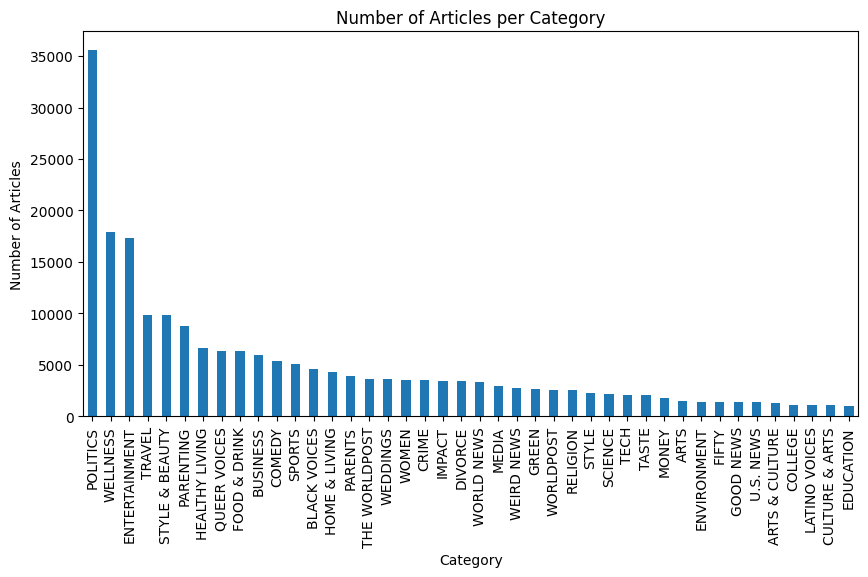

In [ ]:
#overview of categories
print(df['category'].value_counts())

#plot number of articles per categories
plt.figure(figsize=(10, 5))
df['category'].value_counts().plot(kind='bar')
plt.title('Number of Articles per Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.savefig('Number of Articles per Category.jpg', dpi=300)

<ipython-input-7-4622004ea0e7>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  political_human_news['date'] = pd.to_datetime(df['date'])
<ipython-input-7-4622004ea0e7>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  political_human_news['year'] = political_human_news['date'].dt.year


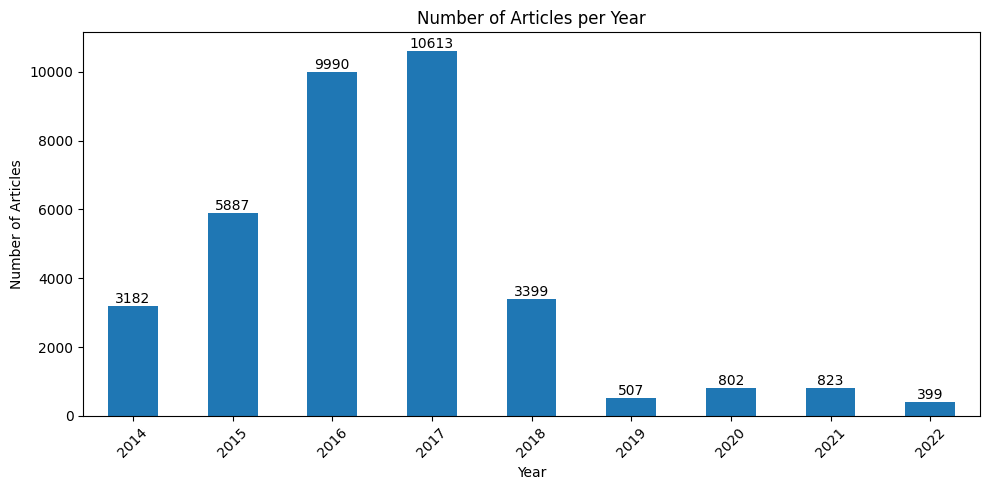

In [ ]:
#create subset that only contains political articles

political_human_news = df[df['category'] == 'POLITICS']

#plot articles in politics per year

#ensure date format is correct
political_human_news['date'] = pd.to_datetime(df['date'])

#extract year
political_human_news['year'] = political_human_news['date'].dt.year

#count articles per year
year_counts = political_human_news['year'].value_counts().sort_index()

#plot article year count
plt.figure(figsize=(10, 5))
ax = year_counts.plot(kind='bar')

#add data labels
for container in ax.containers:
    ax.bar_label(container)

plt.title('Number of Articles per Year')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Number of Articles per Year.jpg', dpi=300)
plt.show()

## 1.1 Dataset preparation/loading

In [ ]:
#create subset that only contains political articles from 2017
political_human_news_2017 = political_human_news[political_human_news['year'] == 2017]

<ipython-input-7-0a0e535afbeb>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  political_human_news_2017['headline_word_count'] = political_human_news_2017['headline'].apply(lambda x: len(str(x).split()))


Average word count in headline: 10.39
Maximum word count in headline: 27
Minimum word count in headline: 1
Number of articles with no headline: 0


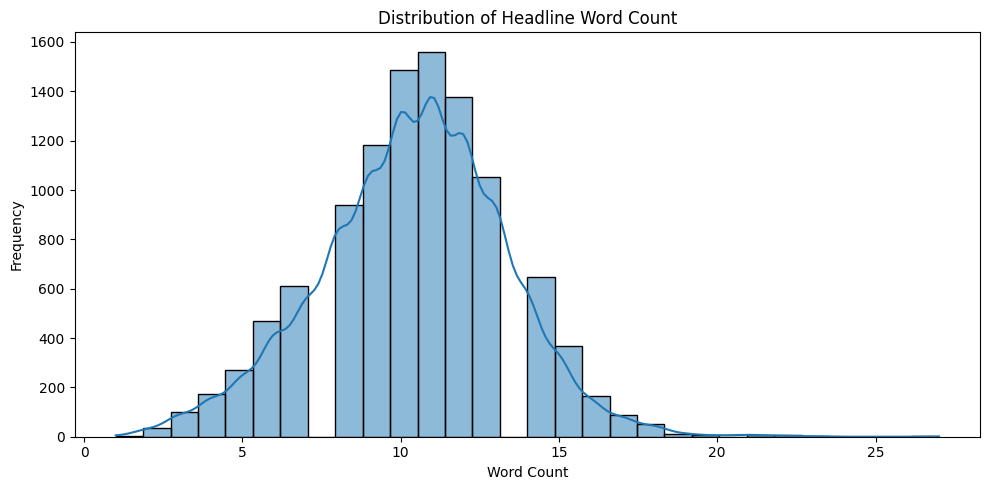

<ipython-input-7-0a0e535afbeb>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  political_human_news_2017['short_description_word_count'] = political_human_news_2017['short_description'].apply(lambda x: len(str(x).split()))


Average word count in short description: 14.98
Maximum word count in short description: 78
Minimum word count in short description: 1
Number of articles with no short description: 0


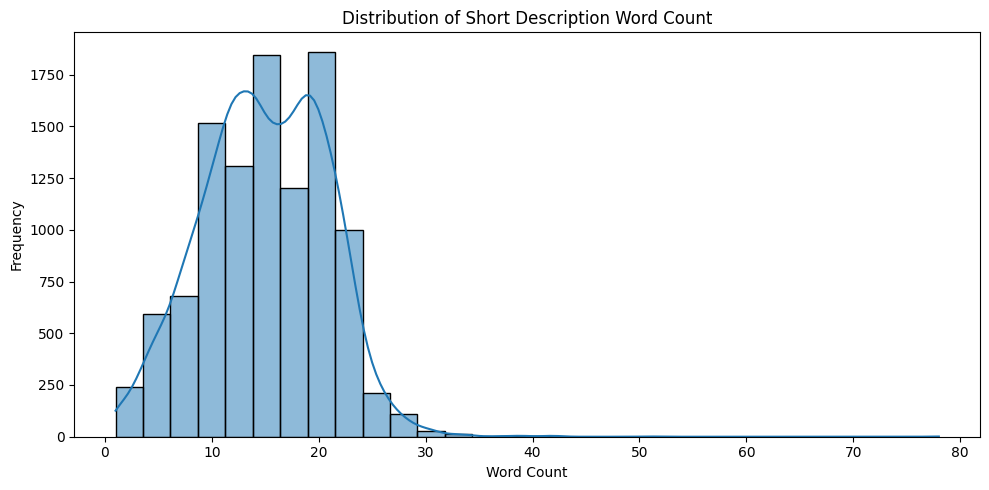

In [ ]:
#distribution of words for prompting

#count average, minimum and maximum words in headline
political_human_news_2017['headline_word_count'] = political_human_news_2017['headline'].apply(lambda x: len(str(x).split()))
average_headline_word_count = political_human_news_2017['headline_word_count'].mean()
print(f"Average word count in headline: {average_headline_word_count:.2f}")
max_headline_word_count = political_human_news_2017['headline_word_count'].max()
print(f"Maximum word count in headline: {max_headline_word_count}")
min_headline_word_count = political_human_news_2017['headline_word_count'].min()
print(f"Minimum word count in headline: {min_headline_word_count}")

#count how many have no headline by checking for average word count
no_headline_count = political_human_news_2017[political_human_news_2017['headline_word_count'] == 0].shape[0]
print(f"Number of articles with no headline: {no_headline_count}")

#plot distribution of headline word count
plt.figure(figsize=(10, 5))
sns.histplot(political_human_news_2017['headline_word_count'], bins=30, kde=True)
plt.title('Distribution of Headline Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Distribution of Headline Word Count.jpg', dpi=300)
plt.show()

#count average, maximum and minimum words in short description
political_human_news_2017['short_description_word_count'] = political_human_news_2017['short_description'].apply(lambda x: len(str(x).split()))
average_short_description_word_count = political_human_news_2017['short_description_word_count'].mean()
print(f"Average word count in short description: {average_short_description_word_count:.2f}")
max_short_description_word_count = political_human_news_2017['short_description_word_count'].max()
print(f"Maximum word count in short description: {max_short_description_word_count}")
min_short_description_word_count = political_human_news_2017['short_description_word_count'].min()
print(f"Minimum word count in short description: {min_short_description_word_count}")

#count how many have no short description by checking for average word count
no_short_description_count = political_human_news_2017[political_human_news_2017['short_description_word_count'] == 0].shape[0]
print(f"Number of articles with no short description: {no_short_description_count}")

#plot distribution of short description word count
plt.figure(figsize=(10, 5))
sns.histplot(political_human_news_2017['short_description_word_count'], bins=30, kde=True)
plt.title('Distribution of Short Description Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Distribution of Short Description Word Count.jpg', dpi=300)
plt.show()

In [ ]:
#check authors to ensure that not all articles are written by the same author
print(political_human_news_2017['authors'].value_counts())
print(political_human_news_2017['authors'].nunique())

authors
Sam Levine                                                                                        282
Mary Papenfuss                                                                                    281
Igor Bobic                                                                                        239
Marina Fang                                                                                       237
Lauren Weber                                                                                      232
                                                                                                 ... 
Joseph Ax, Reuters                                                                                  1
Rep. Sheila Jackson Lee, ContributorU.S. Representative, Texas's 18th Congressional District        1
Joseph Hinchliffe, Reuters                                                                          1
Chris Kenning and Joseph Ax, Reuters                                      

In [ ]:
#load ai generated news dataset
political_AI_news_2017 = pd.read_csv('llama_huffpost_dataset.csv')
print(political_AI_news_2017.head())

                                            headline  \
0  Trump Says He Won't Concede, Vows To 'Keep Fig...   
1  White House Announces New Iran Sanctions, Vows...   
2  Trump Rips CNN In Epic Rant: "They're Not Even...   
3  Trump's "Squad" Targeted In New Campaign Finan...   
4  Trump's Ousters: White House Veterans Expose P...   

                                         description  
0  President Donald Trump vowed to "keep fighting...  
1  The move is the latest escalation in a tense s...  
2  The president continued his tirade against the...  
3  The allegations come as the president's campai...  
4  The latest allegations come as the House Judic...  


In [ ]:
#merge the dataset
#rename 'description' to 'short_description' in AI-generated news dataset
political_AI_news_2017.rename(columns={'description': 'short_description'}, inplace=True)

#add labels for AI and human
political_human_news_2017['label'] = 0
political_AI_news_2017['label'] = 1

#select columns to be combined on
shared_columns = ['headline', 'short_description', 'label']
human = political_human_news_2017[shared_columns]
AI = political_AI_news_2017[shared_columns]

#merge and shuffle
political_2017 = pd.concat([human, AI], ignore_index=True)
political_2017 = political_2017.sample(frac=1, random_state=42).reset_index(drop=True)

#check an example
print(political_2017['label'].value_counts())
print(political_2017.head())


label
0    10613
1     9998
Name: count, dtype: int64
                                            headline  \
0  Pennsylvania Governor: Women Can 'Make Their O...   
1  Trump’s Outsourcing Of War Decision-Making Wor...   
2  Trump's 2024 Campaign Slogan Revealed: "Make A...   
3  Trump To Nominate Huntsman As Russia Ambassado...   
4  Trump's Popularity Surges Post-Impeachment, Po...   

                                   short_description  label  
0  Gov. Tom Wolf plans to veto a highly restricti...      0  
1  But Republicans say they're OK with the Pentag...      0  
2  The slogan has already sparked a mix of reacti...      1  
3  If confirmed, Huntsman will head to Moscow as ...      0  
4  The latest survey from the Pew Research Center...      1  


<ipython-input-10-8d8913f6c20e>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  political_human_news_2017['label'] = 0


In [ ]:
#remove rows that are empty
political_2017 = political_2017.dropna(subset=['headline', 'short_description'])

## 1.2 Pre-processing

In [ ]:
#pre-proccessing of data with spaCy

#load spaCy's English model
spacy.cli.download('en_core_web_md')
new_lemma = spacy.load('en_core_web_md')

#preprocessing function
def preprocess_with_features(text, prefix=""):
    doc = new_lemma(text)

    #lemmatize, lowercase, remove stopwords and non-alphabetic words
    clean_tokens = [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha and not token.is_stop
    ]
    processed_text = " ".join(clean_tokens)

    #POS tag counts
    pos_counts = doc.count_by(spacy.attrs.POS)
    pos_summary = {f"{prefix}POS_{doc.vocab[pos].text}": count for pos, count in pos_counts.items()}

    #NER counts, focused on political entities
    entity_types = ["PERSON", "ORG", "GPE", "NORP", "DATE", "EVENT", "LAW"]
    ner_summary = {f"{prefix}NER_{label}": 0 for label in entity_types}
    for ent in doc.ents:
        key = f"{prefix}NER_{ent.label_}"
        if key in ner_summary:
            ner_summary[key] += 1
    ner_summary[f"{prefix}NER_TOTAL"] = len(doc.ents)

    #combine all features into a flat dictionary
    return {
        f"{prefix}processed_text": processed_text,
        **pos_summary,
        **ner_summary,
    }

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
#apply to headline and description

political_2017['headline_processed'] = political_2017['headline'].apply(new_lemma)
political_2017['description_processed'] = political_2017['short_description'].apply(new_lemma)

#convert doc to clean text
def doc_to_text(doc):
    return " ".join([t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop])

#save cleaned text as columns
political_2017['headline_clean'] = political_2017['headline_processed'].apply(doc_to_text)
political_2017['description_clean'] = political_2017['description_processed'].apply(doc_to_text)
political_2017['combined_text'] = (
    political_2017['headline_processed'].apply(doc_to_text) + " " +
    political_2017['description_processed'].apply(doc_to_text)
)

#display in pretty table
def display_doc_features(df, text_col, doc_col, prefix="head_", limit=10):
    table = PrettyTable(["Index", "Original Text", "Lemmatized Text", "POS Summary", "NER Summary"])

    for idx, row in df.head(limit).iterrows():
        doc = row[doc_col]

        #clean lemmatized text
        lemmatized = " ".join([t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop])

        #POS summary
        pos_counts = Counter([t.pos_ for t in doc if t.is_alpha])

        #NER summary
        ner_labels = [ent.label_ for ent in doc.ents]
        ner_counts = Counter(ner_labels)

        table.add_row([
            idx,
            row[text_col],
            lemmatized,
            dict(pos_counts),
            dict(ner_counts)
        ])

    print(table)

#display
display_doc_features(political_2017, 'headline', 'headline_processed', prefix='head_')
display_doc_features(political_2017, 'short_description', 'description_processed', prefix='desc_')

+-------+----------------------------------------------------------------------------------------+---------------------------------------------------------------+----------------------------------------------------------------------------+---------------------------------------------+
| Index |                                     Original Text                                      |                        Lemmatized Text                        |                                POS Summary                                 |                 NER Summary                 |
+-------+----------------------------------------------------------------------------------------+---------------------------------------------------------------+----------------------------------------------------------------------------+---------------------------------------------+
|   0   |        Pennsylvania Governor: Women Can 'Make Their Own Health Care Decisions'         |       pennsylvania governor woman health ca

In [ ]:
#create csv
political_2017.to_csv('political_2017.csv', index=False)

## 1.3 Data Cleaning

In [ ]:
#check for missing values, duplicates, and data types
print(political_2017.isnull().sum())
print(political_2017.isna().sum())
print(political_2017.duplicated().sum())
print((political_2017['headline'] == '').sum())
print((political_2017['short_description'] == '').sum())

#drop na, empty rows and dublicates after the preprocessing
political_2017.dropna(inplace=True)
political_2017.drop_duplicates(inplace=True)
political_2017 = political_2017[political_2017['headline'] != '']
political_2017 = political_2017[political_2017['short_description'] != '']

headline                 0
short_description        0
label                    0
headline_processed       0
description_processed    0
headline_clean           0
description_clean        0
combined_text            0
dtype: int64
headline                 0
short_description        0
label                    0
headline_processed       0
description_processed    0
headline_clean           0
description_clean        0
combined_text            0
dtype: int64
0
0
0


# 2 Feature engineering

##2.1 Descriptive Analysis

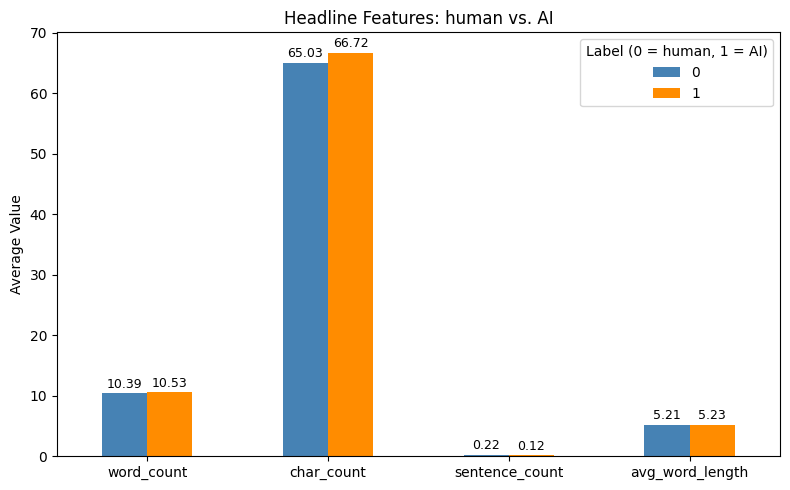

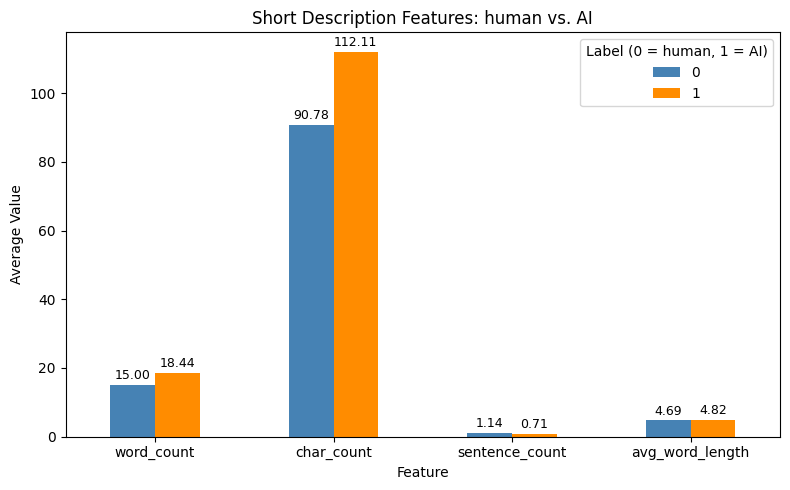

In [ ]:
#understanding if length differs in text features

def extract_text_features(text):
    tokens = text.split()
    types = set(tokens)

    #calculate average word length
    word_lengths = [len(token) for token in tokens if token.isalpha()]
    avg_word_length = sum(word_lengths) / len(word_lengths) if word_lengths else 0

    features = {
        "word_count": len(tokens),
        "char_count": len(text),
        "sentence_count": len(re.findall(r'[.!?]+', text)),
        "avg_word_length": avg_word_length
    }

    return features

#apply data
headline_features = political_2017['headline'].apply(extract_text_features).apply(pd.Series)
headline_features['label'] = political_2017['label']
desc_features = political_2017['short_description'].apply(extract_text_features).apply(pd.Series)
desc_features['label'] = political_2017['label']

#combine into one tidy DataFrame
text_features = pd.concat([headline_features, desc_features], ignore_index=True)

#calculate means grouped by label
headline_means = headline_features.groupby('label')[['word_count', 'char_count', 'sentence_count', 'avg_word_length']].mean()
desc_means = desc_features.groupby('label')[['word_count', 'char_count', 'sentence_count', 'avg_word_length']].mean()

#plot differences

def label_bars(ax, fmt="%.2f"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=9, padding=2)

#HEADLINE
ax = headline_means.T.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'darkorange'])
plt.title("Headline Features: human vs. AI")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Headline Features: human vs. AI.jpg', dpi=300)
plt.show()

#SHORT DESCRIPTION
ax = desc_means.T.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'darkorange'])
plt.title("Short Description Features: human vs. AI")
plt.ylabel("Average Value")
plt.xlabel("Feature")
plt.xticks(rotation=0)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Short Description Features: human vs AI.jpg', dpi=300)
plt.show()






## 2.2 Lexical analysis




### 2.2.1 POS Analysis

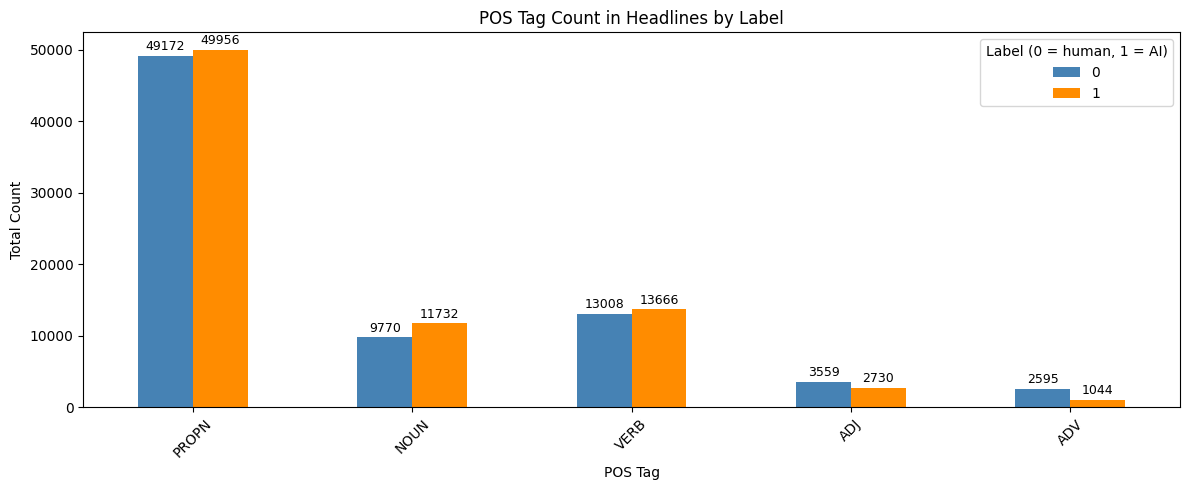

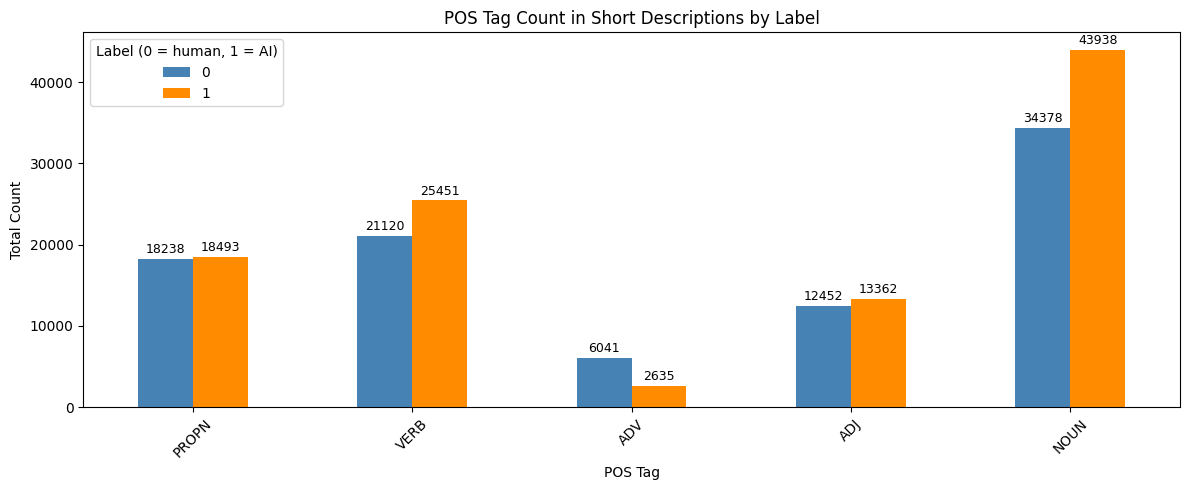

In [ ]:
#POS

#POS tags we are interested in
pos_tags = ['VERB', 'NOUN', 'ADJ', 'ADV', 'PROPN']

def count_pos_tags_by_label(doc_series, labels, pos_tags):
    doc_pos_counts = [Counter(t.pos_ for t in doc if t.pos_ in pos_tags and t.is_alpha) for doc in doc_series]

    #convert to DataFrame
    pos_df = pd.DataFrame(doc_pos_counts).fillna(0)
    pos_df['label'] = labels.values

    #group and sum
    grouped = pos_df.groupby('label').sum().T
    return grouped

#apply to headline and description
headline_pos_summary = count_pos_tags_by_label(political_2017['headline_processed'], political_2017['label'], pos_tags)
desc_pos_summary = count_pos_tags_by_label(political_2017['description_processed'], political_2017['label'], pos_tags)

#plot
def plot_pos_distribution(pos_summary, title):
    ax = pos_summary.plot(kind='bar', figsize=(12, 5), color=['steelblue', 'darkorange'])
    plt.title(title)
    plt.ylabel("Total Count")
    plt.xlabel("POS Tag")
    plt.xticks(rotation=45)
    plt.legend(title="Label (0 = human, 1 = AI)")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9, padding=2)
    plt.tight_layout()
    plt.savefig(f'{title}.jpg', dpi=300)
    plt.show()

plot_pos_distribution(headline_pos_summary, "POS Tag Count in Headlines by Label")
plot_pos_distribution(desc_pos_summary, "POS Tag Count in Short Descriptions by Label")

###2.2.2 NER Analysis

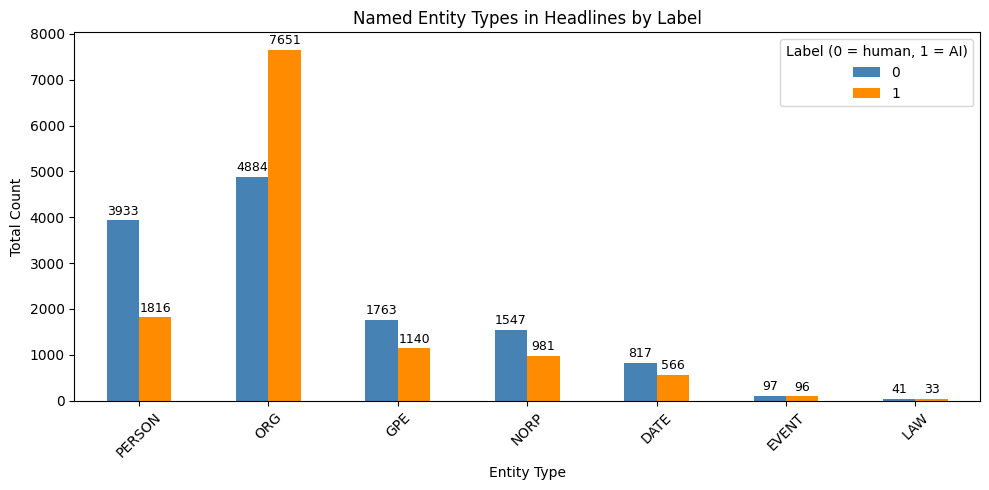

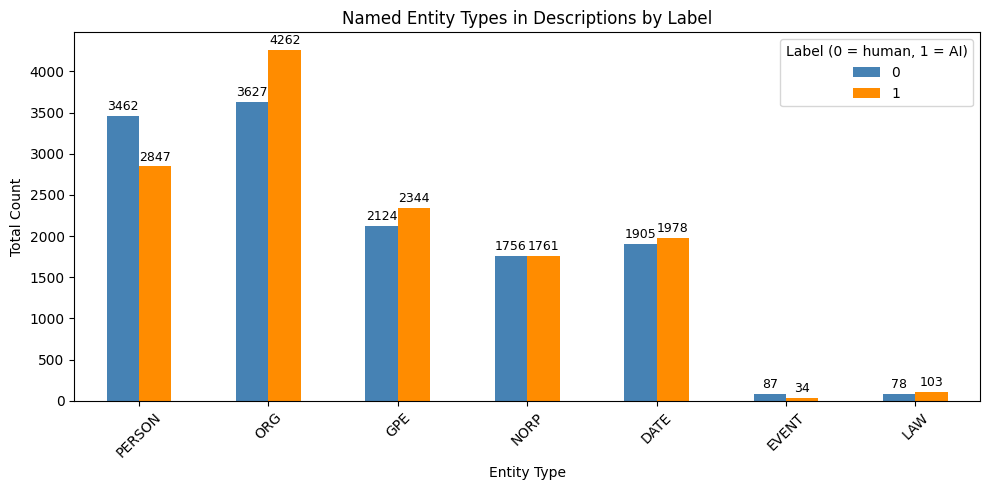

In [ ]:
#NER analysis

#define the entity types that are relevant for politics
ner_labels = ["PERSON", "ORG", "GPE", "NORP", "DATE", "EVENT", "LAW"]

#function to count NER labels in a spaCy Doc
def get_ner_counts(doc):
    ner_counter = Counter(ent.label_ for ent in doc.ents if ent.label_ in ner_labels)
    return {label: ner_counter.get(label, 0) for label in ner_labels}

#apply to headline and description docs
headline_ner_df = political_2017['headline_processed'].apply(get_ner_counts).apply(pd.Series)
headline_ner_df['label'] = political_2017['label']
desc_ner_df = political_2017['description_processed'].apply(get_ner_counts).apply(pd.Series)
desc_ner_df['label'] = political_2017['label']

#group by label and transpose for plotting
headline_grouped = headline_ner_df.groupby('label').sum().T
desc_grouped = desc_ner_df.groupby('label').sum().T

#plotting function
def label_bars(ax, fmt="%.0f"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=9, padding=2)

#HEADLINES
ax = headline_grouped.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange'])
plt.title("Named Entity Types in Headlines by Label")
plt.ylabel("Total Count")
plt.xlabel("Entity Type")
plt.xticks(rotation=45)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Named Entity Types in Headlines by Label.jpg', dpi=300)
plt.show()

#SHORT DESCRIPTIONS
ax = desc_grouped.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange'])
plt.title("Named Entity Types in Descriptions by Label")
plt.ylabel("Total Count")
plt.xlabel("Entity Type")
plt.xticks(rotation=45)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Named Entity Types in Descriptions by Label.jpg', dpi=300)
plt.show()


###2.2.3 Special Character Analysis

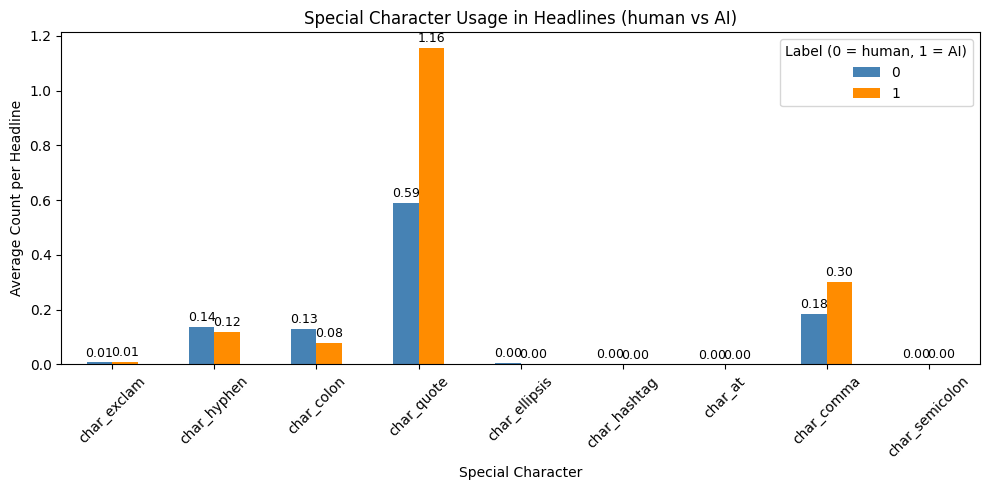

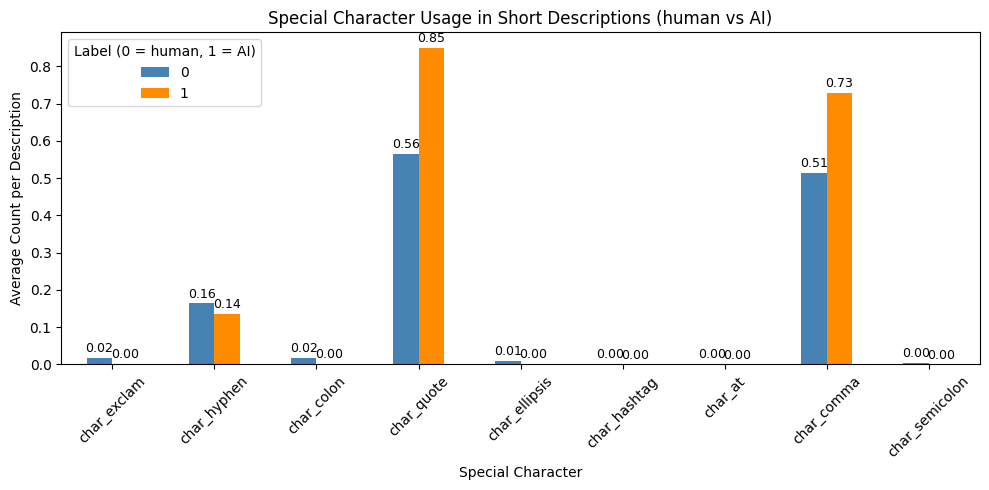

In [ ]:
#analyze special characters

def extract_text_features(text):
    special_chars = {
        "char_exclam": text.count("!"),
        "char_hyphen": text.count("-"),
        "char_colon": text.count(":"),
        "char_quote": text.count('"') + text.count("'"),
        "char_ellipsis": text.count("…") + text.count("..."),
        "char_hashtag": text.count("#"),
        "char_at": text.count("@"),
        "char_comma": text.count(","),
        "char_semicolon": text.count(";"),
    }
    return {**special_chars}

#apply to both headline and short_description
headline_chars = political_2017['headline'].apply(extract_text_features).apply(pd.Series)
desc_chars = political_2017['short_description'].apply(extract_text_features).apply(pd.Series)

#add label and text type info
headline_chars['label'] = political_2017['label']
headline_chars['TextType'] = 'Headline'
desc_chars['label'] = political_2017['label']
desc_chars['TextType'] = 'Short Description'

#combine for grouped plotting
all_chars = pd.concat([headline_chars, desc_chars], ignore_index=True)

#features to plot
char_features = ['char_exclam', 'char_hyphen', 'char_colon', 'char_quote', 'char_ellipsis', 'char_hashtag', 'char_at','char_comma','char_semicolon']

#plot

def label_bars(ax, fmt="%.2f"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=9, padding=2)

#HEADLINE
headline_plot = all_chars[all_chars['TextType'] == 'Headline']
headline_means = headline_plot.groupby('label')[char_features].mean().T

ax = headline_means.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange'])
plt.title("Special Character Usage in Headlines (human vs AI)")
plt.ylabel("Average Count per Headline")
plt.xlabel("Special Character")
plt.xticks(rotation=45)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Special Character Usage in Headlines (human vs AI).jpg', dpi=300)
plt.show()

#SHORT DESCRIPTION
desc_plot = all_chars[all_chars['TextType'] == 'Short Description']
desc_means = desc_plot.groupby('label')[char_features].mean().T

ax = desc_means.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'darkorange'])
plt.title("Special Character Usage in Short Descriptions (human vs AI)")
plt.ylabel("Average Count per Description")
plt.xlabel("Special Character")
plt.xticks(rotation=45)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Special Character Usage in Short Descriptions (human vs AI).jpg', dpi=300)
plt.show()


###2.2.4 Function-Content Analysis

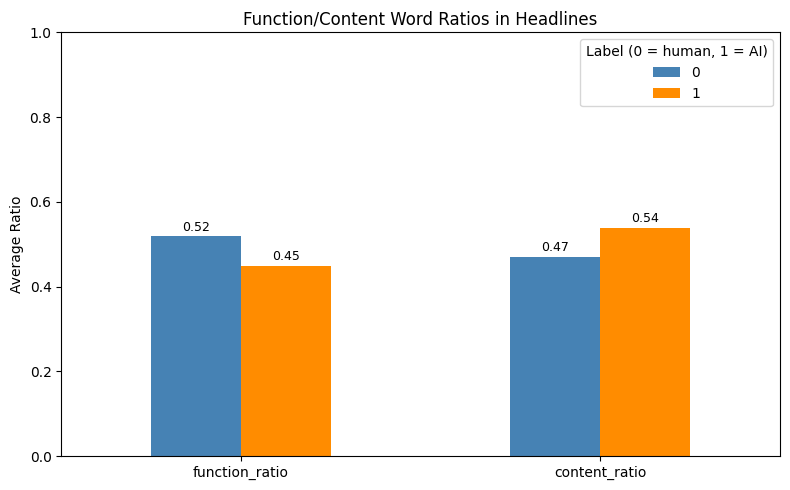

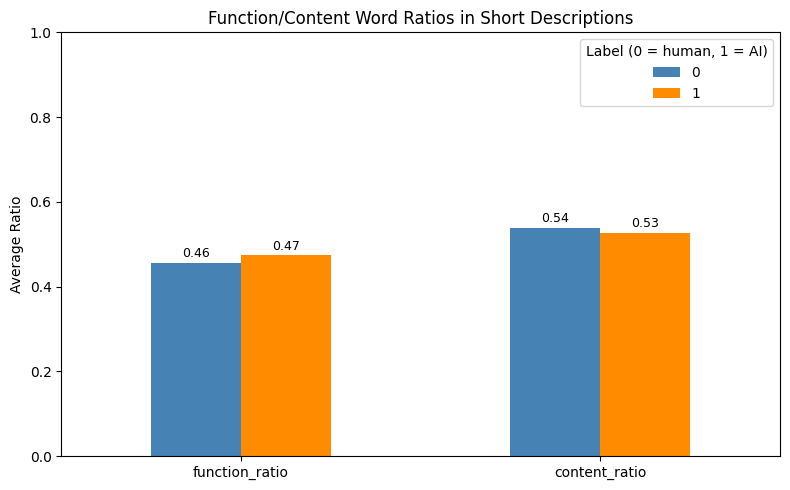

In [ ]:
#function content

#define POS tag groups
function_pos = {"ADP", "AUX", "CCONJ", "DET", "PART", "PRON", "SCONJ"}
content_pos = {"NOUN", "VERB", "ADJ", "ADV"}

#function to compute function/content ratios from a spaCy Doc
def get_function_content_ratios(doc):
    pos_counts = {tag: 0 for tag in function_pos.union(content_pos)}
    for token in doc:
        if token.pos_ in pos_counts and token.is_alpha:
            pos_counts[token.pos_] += 1

    function_count = sum(pos_counts[tag] for tag in function_pos)
    content_count = sum(pos_counts[tag] for tag in content_pos)
    total = function_count + content_count

    return {
        "function_ratio": function_count / total if total else 0,
        "content_ratio": content_count / total if total else 0
    }

#apply to headline and short description
headline_ratios = political_2017['headline_processed'].apply(get_function_content_ratios).apply(pd.Series)
headline_ratios['label'] = political_2017['label']
desc_ratios = political_2017['description_processed'].apply(get_function_content_ratios).apply(pd.Series)
desc_ratios['label'] = political_2017['label']

#group by label
headline_means = headline_ratios.groupby('label')[['function_ratio', 'content_ratio']].mean().T
desc_means = desc_ratios.groupby('label')[['function_ratio', 'content_ratio']].mean().T

#plot
def label_bars(ax, fmt="%.2f"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, label_type="edge", fontsize=9, padding=2)

#HEADLINES
ax = headline_means.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'darkorange'])
plt.title("Function/Content Word Ratios in Headlines")
plt.ylabel("Average Ratio")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Function_Content_Word_Ratios_in_Headlines.jpg', dpi=300)
plt.show()

#SHORT DESCRIPTIONS
ax = desc_means.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'darkorange'])
plt.title("Function/Content Word Ratios in Short Descriptions")
plt.ylabel("Average Ratio")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Label (0 = human, 1 = AI)")
label_bars(ax)
plt.tight_layout()
plt.savefig('Function_Content_Word_Ratios_in_Headlines.jpg', dpi=300)
plt.show()

###2.2.5 TF-IDF Score Analysis

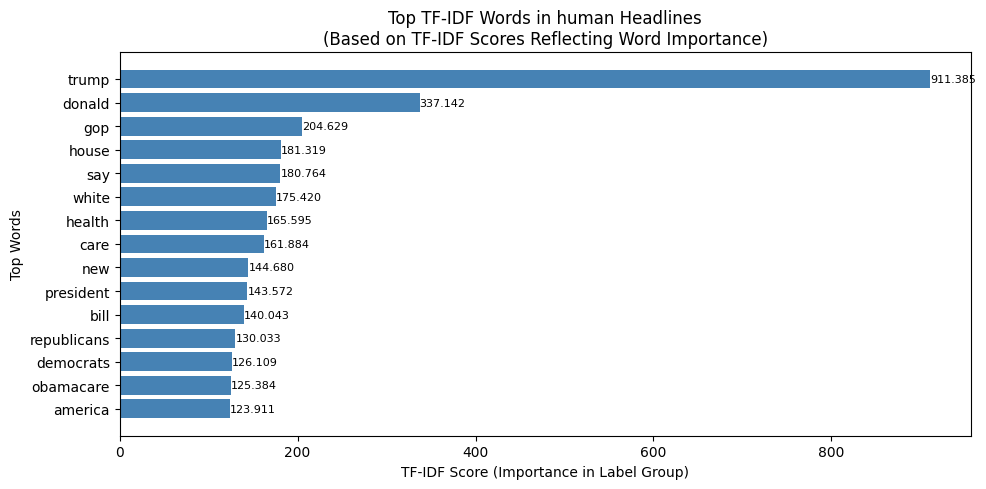

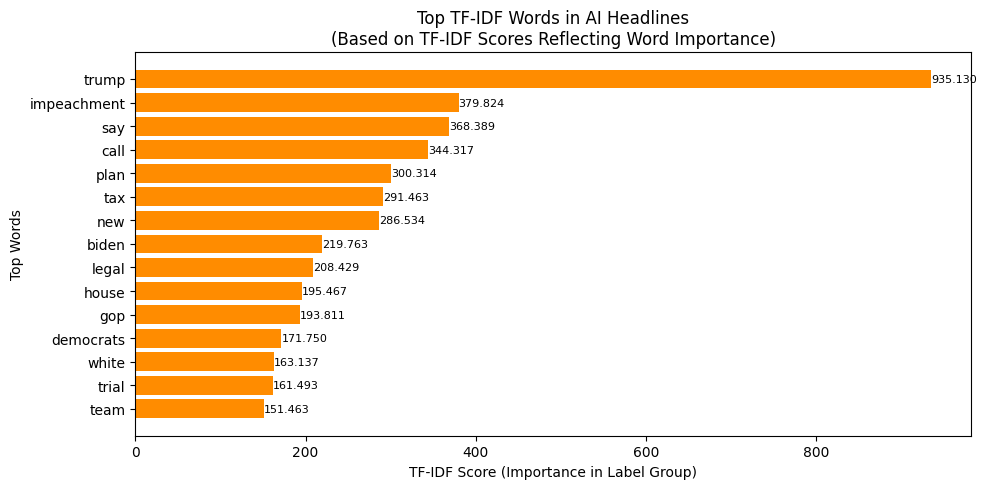

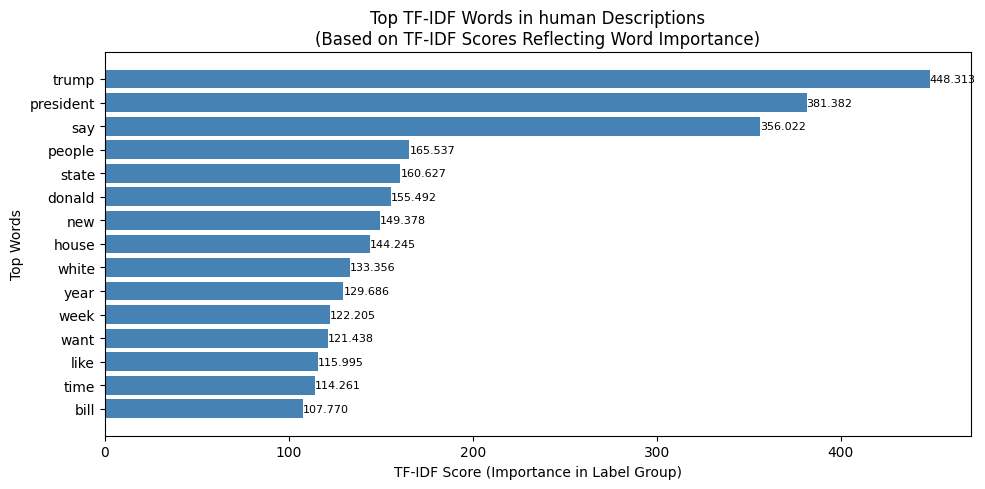

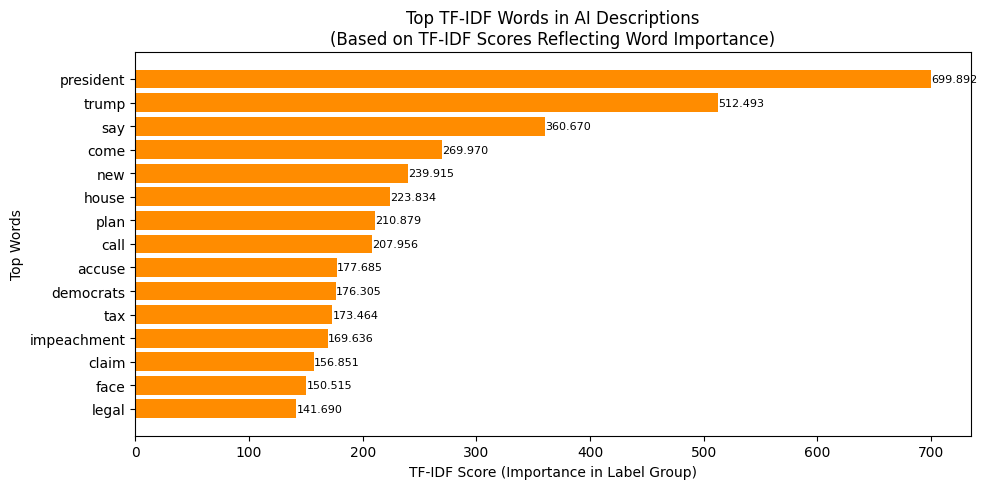

In [ ]:
#TF-IDF Score

def compute_top_tfidf(texts, top_n=15):
    vectorizer = TfidfVectorizer(max_features=500)
    tfidf_matrix = vectorizer.fit_transform(texts)
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
    scores = tfidf_df.sum().sort_values(ascending=False).head(top_n)
    return scores

#create subsets
human_head = political_2017[political_2017['label'] == 0]['headline_clean']
AI_head = political_2017[political_2017['label'] == 1]['headline_clean']
human_desc = political_2017[political_2017['label'] == 0]['description_clean']
AI_desc = political_2017[political_2017['label'] == 1]['description_clean']

#apply
tfidf_human_head = compute_top_tfidf(human_head)
tfidf_AI_head = compute_top_tfidf(AI_head)

tfidf_human_desc = compute_top_tfidf(human_desc)
tfidf_AI_desc = compute_top_tfidf(AI_desc)

#plot
def plot_tfidf_bar(scores, title, color):
    plt.figure(figsize=(10, 5))
    bars = plt.barh(scores.index[::-1], scores.values[::-1], color=color)
    plt.title(f"{title}\n(Based on TF-IDF Scores Reflecting Word Importance)")
    plt.xlabel("TF-IDF Score (Importance in Label Group)")
    plt.ylabel("Top Words")
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{width:.3f}", va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{title}.jpg", dpi=300)
    plt.show()

#HEADLINE
plot_tfidf_bar(tfidf_human_head, "Top TF-IDF Words in human Headlines", color='steelblue')
plot_tfidf_bar(tfidf_AI_head, "Top TF-IDF Words in AI Headlines", color='darkorange')

#SHORT DESCIRPTION
plot_tfidf_bar(tfidf_human_desc, "Top TF-IDF Words in human Descriptions", color='steelblue')
plot_tfidf_bar(tfidf_AI_desc, "Top TF-IDF Words in AI Descriptions", color='darkorange')



###2.2.6 Lexical Richness Analysis

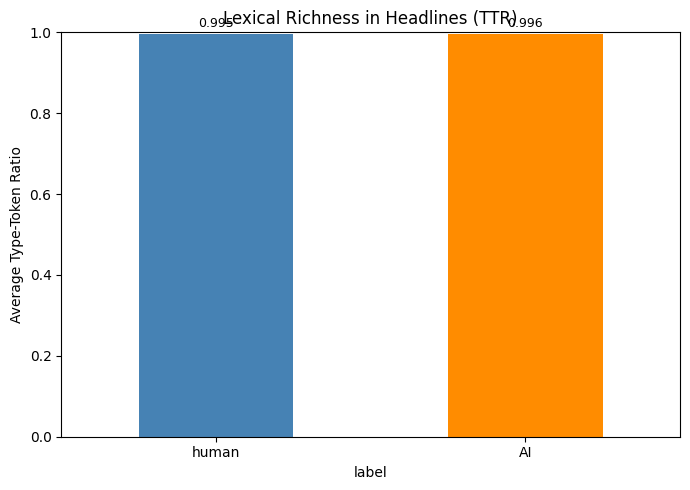

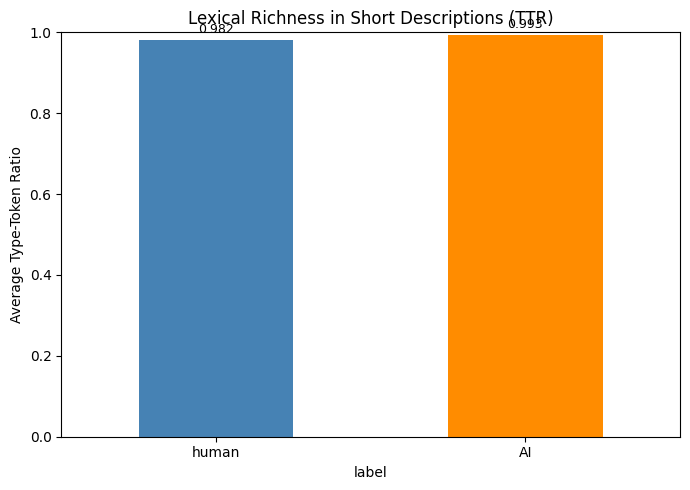

In [ ]:
#lexical richness

#function to compute TTR from a spaCy Doc
def compute_ttr_from_clean(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    tokens = text.split()
    return len(set(tokens)) / len(tokens) if tokens else 0

#compute TTR scores (temporary, not stored)
head_ttr = political_2017['headline_clean'].apply(compute_ttr_from_clean)
desc_ttr = political_2017['description_clean'].apply(compute_ttr_from_clean)

#combine with labels into a temporary DataFrame
ttr_df = pd.DataFrame({
    'label': political_2017['label'],
    'head_ttr': head_ttr,
    'desc_ttr': desc_ttr
})

#group for plotting
headline_ttr_by_label = ttr_df.groupby('label')['head_ttr'].mean()
desc_ttr_by_label = ttr_df.groupby('label')['desc_ttr'].mean()

#plot

def plot_ttr(ttr_series, title, colors):
    ax = ttr_series.plot(kind='bar', color=colors, figsize=(7, 5))
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", label_type="edge", fontsize=9, padding=3)
    plt.title(title)
    plt.ylabel("Average Type-Token Ratio")
    plt.ylim(0, 1)
    plt.xticks(ticks=[0,1], labels=["human", "AI"], rotation=0)
    plt.tight_layout()
    plt.savefig(f"{title}.jpg", dpi=300)
    plt.show()

#HEADLINE
plot_ttr(headline_ttr_by_label, "Lexical Richness in Headlines (TTR)", colors=['steelblue', 'darkorange'])

#SHORT DESCRIPTION
plot_ttr(desc_ttr_by_label, "Lexical Richness in Short Descriptions (TTR)", colors=['steelblue', 'darkorange'])

##2.3 Structural Analysis


###2.3.1 Sentence Structure Analysis

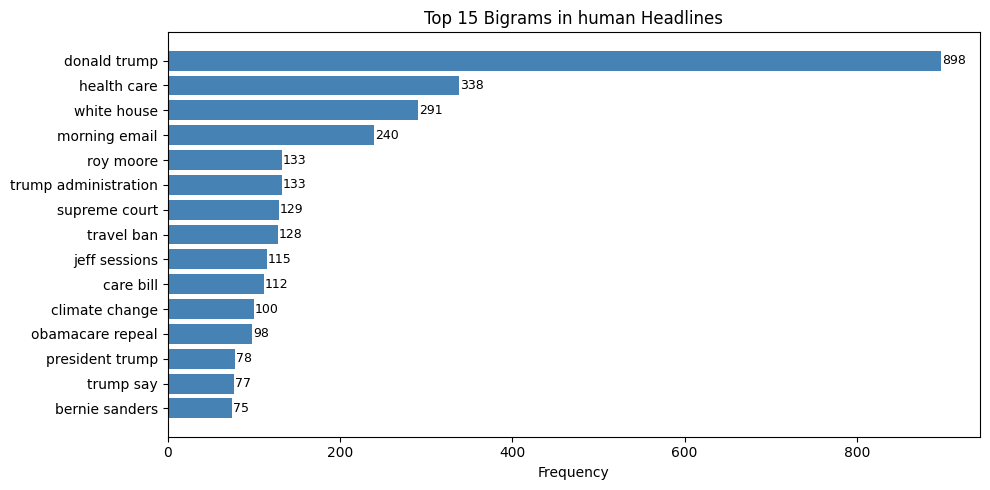

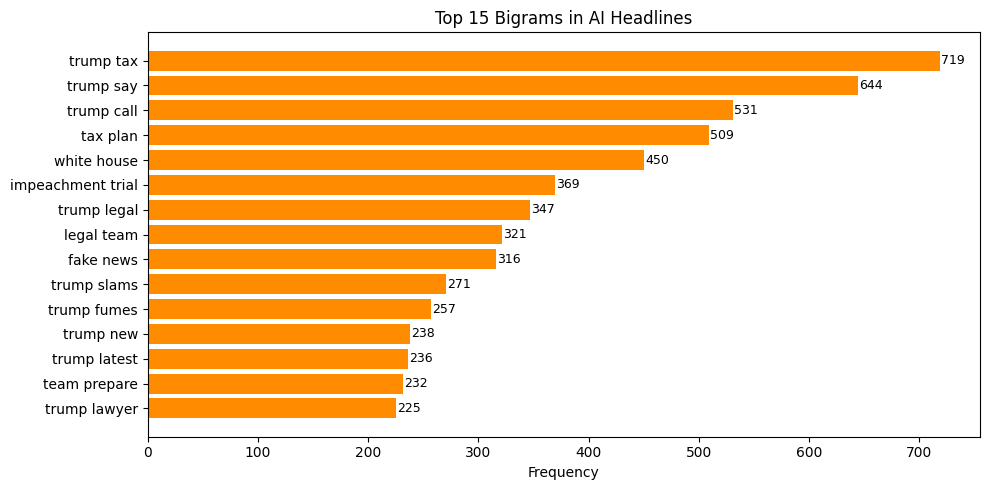

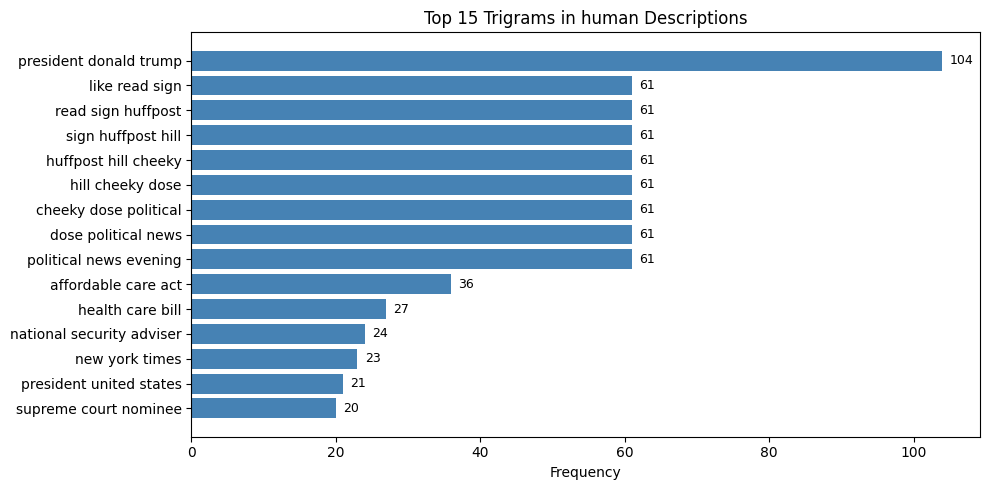

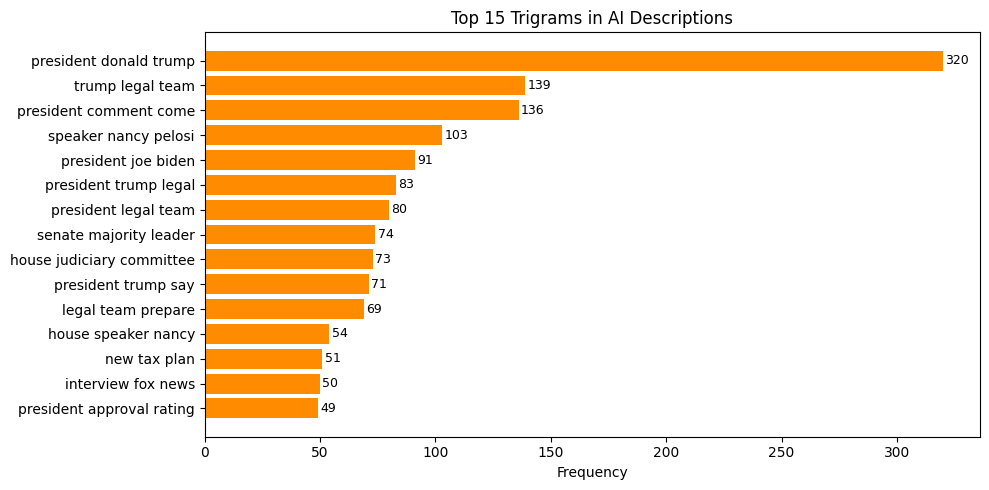

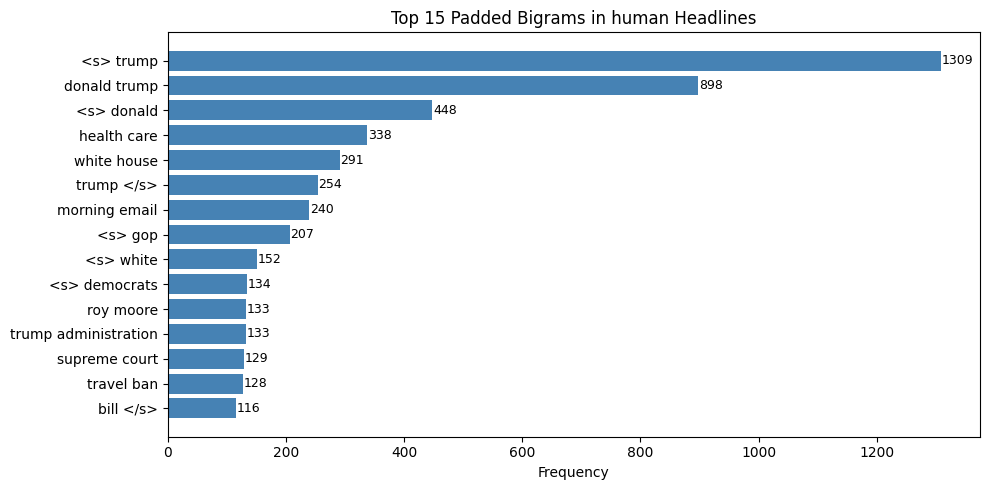

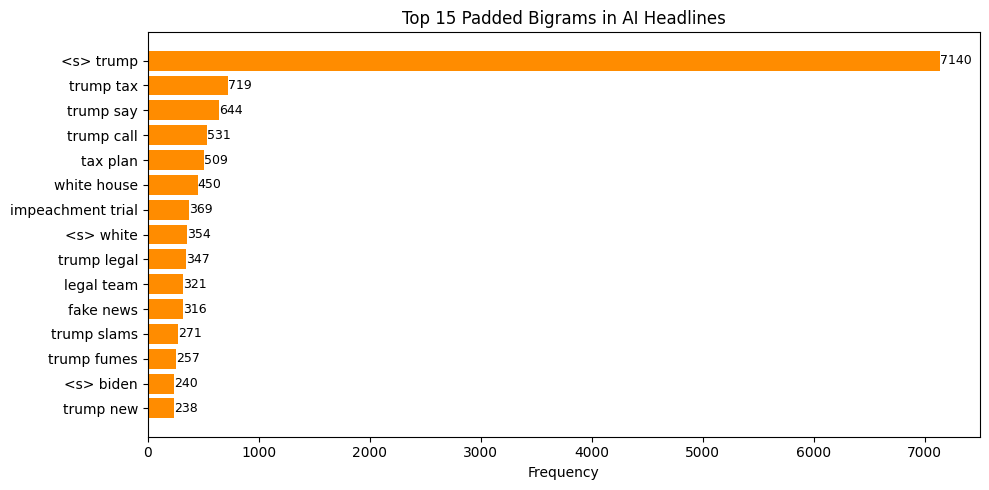

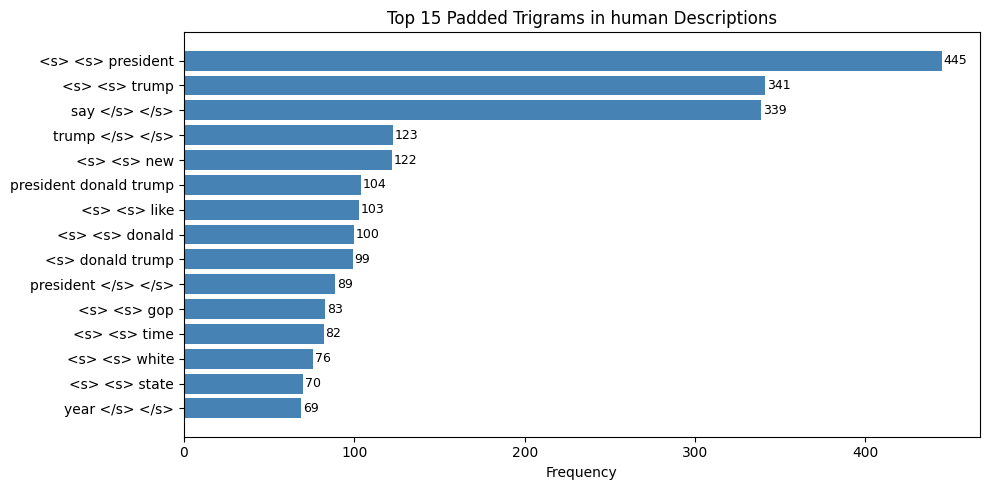

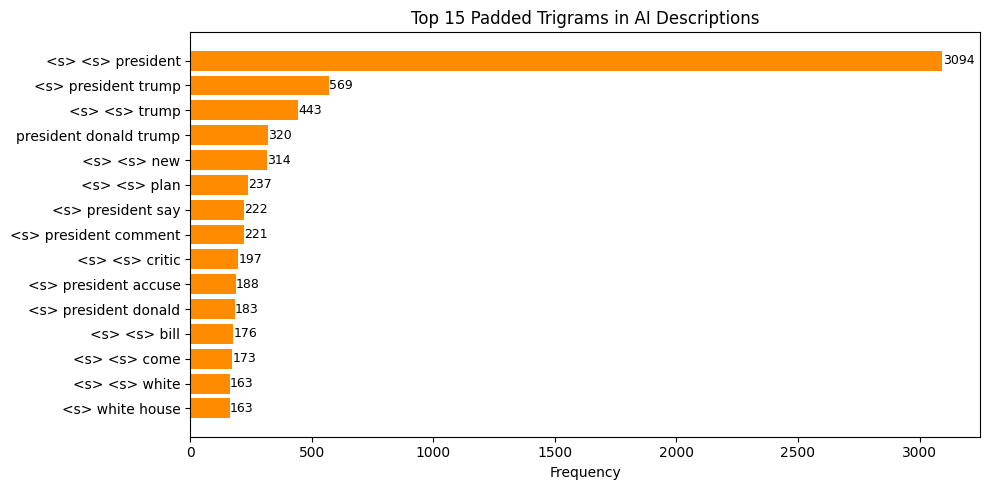

In [ ]:
#sentence structure (n-grams)
def extract_top_ngrams_from_clean_text(text_series, n=2, top_n=20, use_padding=False):
    all_ngrams = []
    for text in text_series:
        tokens = text.split()
        if use_padding:
            tokens = list(pad_sequence(tokens, n=n, pad_left=True, pad_right=True,
                                       left_pad_symbol="<s>", right_pad_symbol="</s>"))
        all_ngrams.extend(ngrams(tokens, n))
    return Counter(all_ngrams).most_common(top_n)

#unpadded bigrams and trigrams
human_head_bigrams = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 0, 'headline_clean'], n=2, top_n=15)
AI_head_bigrams = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 1, 'headline_clean'], n=2, top_n=15)

human_desc_trigrams = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 0, 'description_clean'], n=3, top_n=15)
AI_desc_trigrams = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 1, 'description_clean'], n=3, top_n=15)

#padded versions
human_head_bigrams_pad = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 0, 'headline_clean'], n=2, top_n=15, use_padding=True)
AI_head_bigrams_pad = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 1, 'headline_clean'], n=2, top_n=15, use_padding=True)

human_desc_trigrams_pad = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 0, 'description_clean'], n=3, top_n=15, use_padding=True)
AI_desc_trigrams_pad = extract_top_ngrams_from_clean_text(political_2017.loc[political_2017['label'] == 1, 'description_clean'], n=3, top_n=15, use_padding=True)

#plot

def plot_ngrams(ngram_list, title, color='mediumseagreen'):
    phrases = [' '.join(ngram) for ngram, count in ngram_list]
    counts = [count for _, count in ngram_list]

    plt.figure(figsize=(10, 5))
    bars = plt.barh(phrases[::-1], counts[::-1], color=color)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()

    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height() / 2, str(int(width)), va='center', fontsize=9)
    plt.savefig(f"{title}.jpg", dpi=300)
    plt.show()

#unpadded
plot_ngrams(human_head_bigrams, "Top 15 Bigrams in human Headlines", color='steelblue')
plot_ngrams(AI_head_bigrams, "Top 15 Bigrams in AI Headlines", color='darkorange')
plot_ngrams(human_desc_trigrams, "Top 15 Trigrams in human Descriptions", color='steelblue')
plot_ngrams(AI_desc_trigrams, "Top 15 Trigrams in AI Descriptions", color='darkorange')

#padded
plot_ngrams(human_head_bigrams_pad , "Top 15 Padded Bigrams in human Headlines", color='steelblue')
plot_ngrams(AI_head_bigrams_pad , "Top 15 Padded Bigrams in AI Headlines", color='darkorange')
plot_ngrams(human_desc_trigrams_pad, "Top 15 Padded Trigrams in human Descriptions", color='steelblue')
plot_ngrams(AI_desc_trigrams_pad, "Top 15 Padded Trigrams in AI Descriptions", color='darkorange')


###2.3.2 Sentence Start Analysis

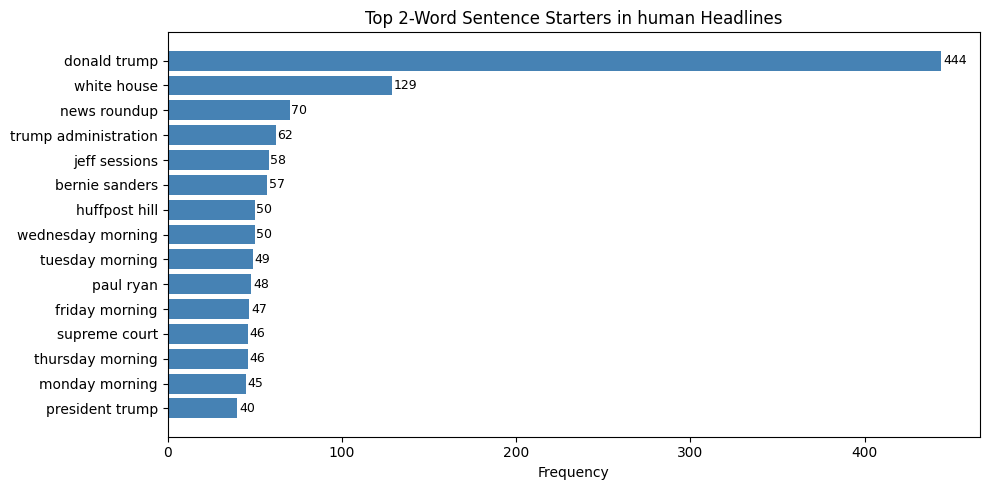

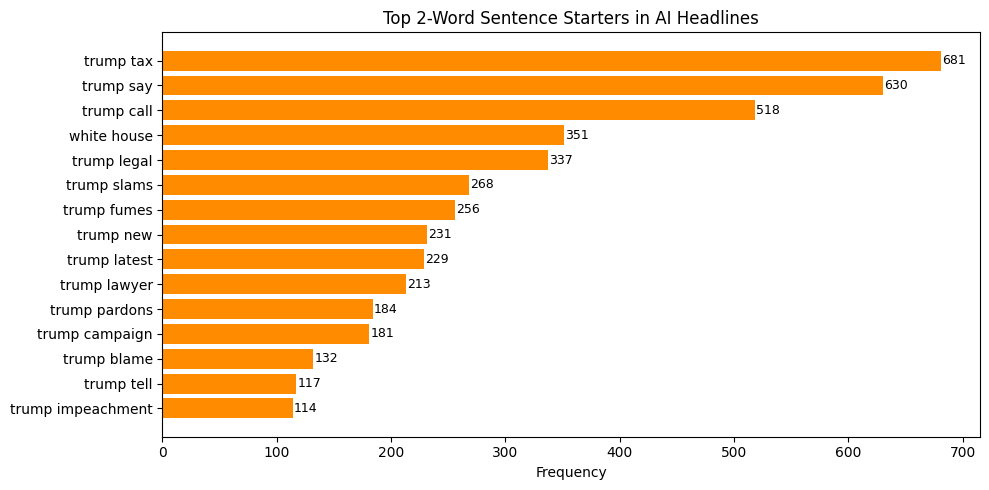

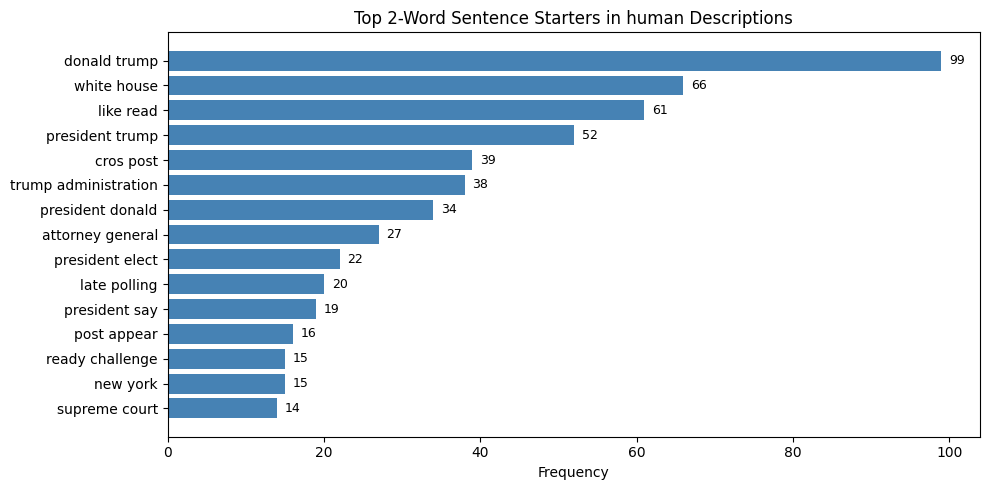

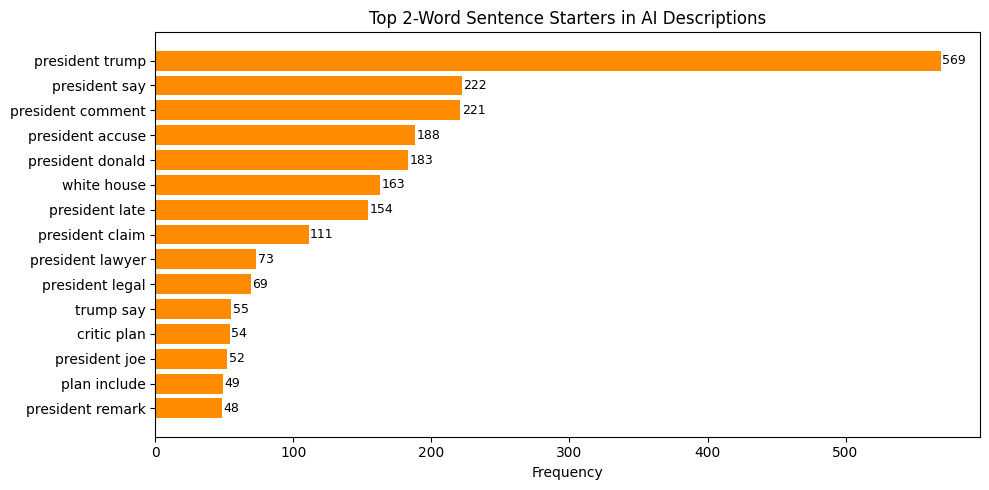

In [ ]:
#understand if certain sentence startes are more common

def extract_sentence_openers_from_clean(text, n_words=2):
    starters = []
    sentences = text.split('.')
    for sent in sentences:
        tokens = [w for w in sent.strip().split() if w.isalpha()]
        if len(tokens) >= n_words:
            phrase = ' '.join(tokens[:n_words])
            starters.append(phrase)

    return starters

#apply to data

#HEADLINES
human_headline_openers = Counter(
    phrase
    for text in political_2017.loc[political_2017['label'] == 0, 'headline_clean']
    for phrase in extract_sentence_openers_from_clean(text, n_words=2)).most_common(15)

AI_headline_openers = Counter(
    phrase
    for text in political_2017.loc[political_2017['label'] == 1, 'headline_clean']
    for phrase in extract_sentence_openers_from_clean(text, n_words=2)).most_common(15)

#DESCRIPTIONS
human_desc_openers = Counter(
    phrase
    for text in political_2017.loc[political_2017['label'] == 0, 'description_clean']
    for phrase in extract_sentence_openers_from_clean(text, n_words=2)).most_common(15)

AI_desc_openers = Counter(
    phrase
    for text in political_2017.loc[political_2017['label'] == 1, 'description_clean']
    for phrase in extract_sentence_openers_from_clean(text, n_words=2)).most_common(15)


#plot

def plot_openers(opener_counts, title, color='teal'):
    phrases, counts = zip(*opener_counts)
    plt.figure(figsize=(10, 5))
    bars = plt.barh(phrases[::-1], counts[::-1], color=color)
    plt.title(title)
    plt.xlabel("Frequency")
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 1, bar.get_y() + bar.get_height() / 2, str(int(width)), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{title}.jpg", dpi=300)
    plt.show()

plot_openers(human_headline_openers, "Top 2-Word Sentence Starters in human Headlines", color='steelblue')
plot_openers(AI_headline_openers, "Top 2-Word Sentence Starters in AI Headlines", color='darkorange')
plot_openers(human_desc_openers, "Top 2-Word Sentence Starters in human Descriptions", color='steelblue')
plot_openers(AI_desc_openers, "Top 2-Word Sentence Starters in AI Descriptions", color='darkorange')


###2.3.3 Conjunction Analysis

In [ ]:
#total count of conjunctions

def get_all_conjunction_counts_from_docs(doc_series):
    conjunction_counts = Counter()

    for doc in doc_series:
        for token in doc:
            if token.dep_ in {'cc', 'mark'}:
                conjunction_counts[token.text.lower()] += 1

    return conjunction_counts

#apply
human_head_conj_counts = get_all_conjunction_counts_from_docs(
    political_2017.loc[political_2017['label'] == 0, 'headline_processed'])

AI_head_conj_counts = get_all_conjunction_counts_from_docs(
    political_2017.loc[political_2017['label'] == 1, 'headline_processed'])

human_desc_conj_counts = get_all_conjunction_counts_from_docs(
    political_2017.loc[political_2017['label'] == 0, 'description_processed'])

AI_desc_conj_counts = get_all_conjunction_counts_from_docs(
    political_2017.loc[political_2017['label'] == 1, 'description_processed'])

#display
print("Total Conjunctions:")
print(f"human Headlines: {sum(human_head_conj_counts.values())}")
print(f"AI Headlines: {sum(AI_head_conj_counts.values())}")
print(f"human Descriptions: {sum(human_desc_conj_counts.values())}")
print(f"AI Descriptions: {sum(AI_desc_conj_counts.values())}")


Total Conjunctions:
human Headlines: 1922
AI Headlines: 1733
human Descriptions: 5591
AI Descriptions: 7101


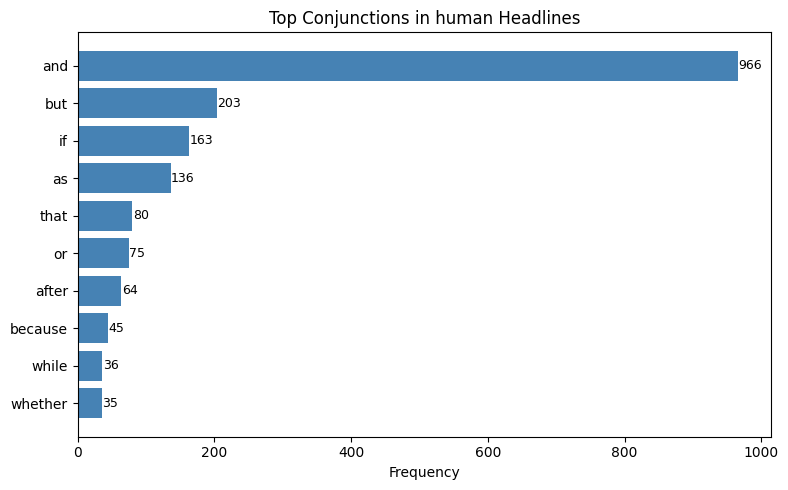

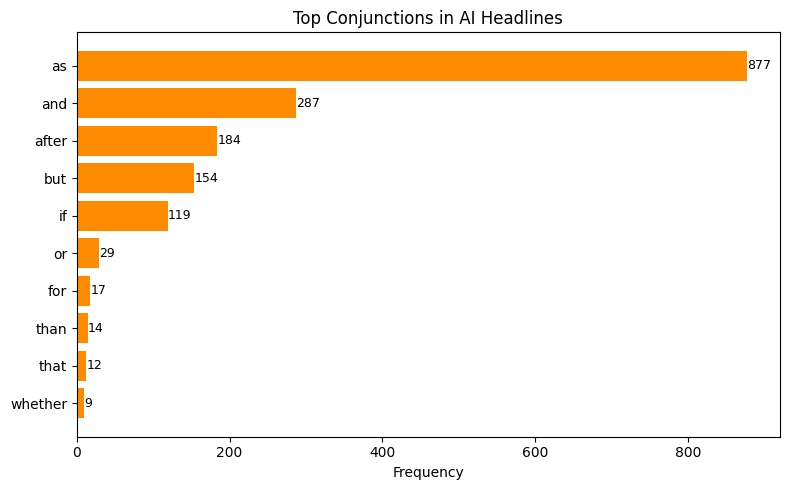

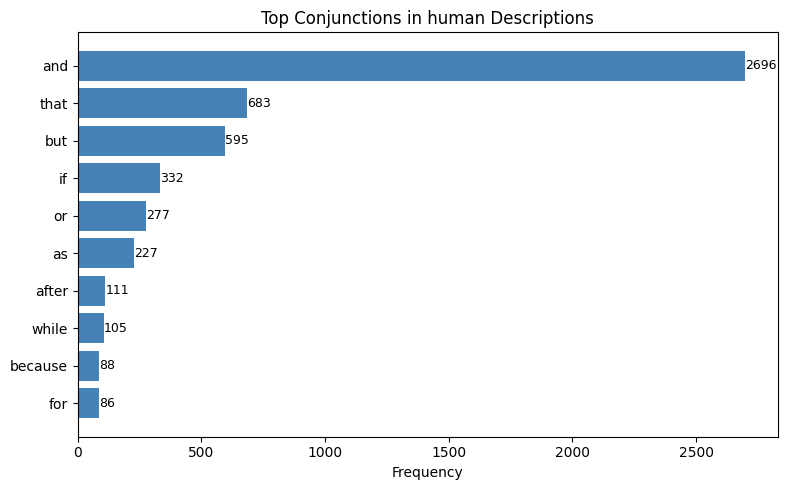

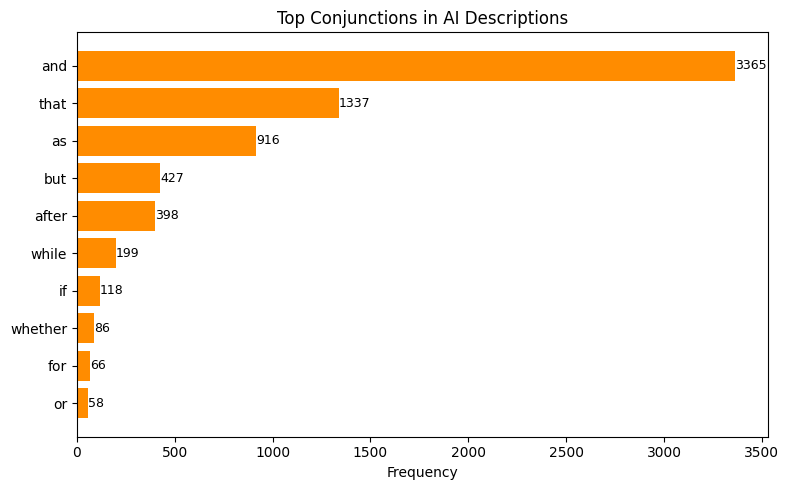

In [ ]:
#analyze most frequent conjuctions

#checks for 'cc': coordinating conjunction and 'mark': marker for subordinate clauses
def get_most_frequent_conjunctions_from_docs(doc_series, top_n=10):
    conjunction_counts = Counter()

    for doc in doc_series:
        for token in doc:
            if token.dep_ in {'cc', 'mark'}:
                conjunction_counts[token.text.lower()] += 1

    return conjunction_counts.most_common(top_n)

#apply to data
#HEADLINES
human_conj_headlines = get_most_frequent_conjunctions_from_docs(
    political_2017.loc[political_2017['label'] == 0, 'headline_processed'])

AI_conj_headlines = get_most_frequent_conjunctions_from_docs(
    political_2017.loc[political_2017['label'] == 1, 'headline_processed'])

#SHORT DESCRIPTIONS
human_conj_descriptions = get_most_frequent_conjunctions_from_docs(
    political_2017.loc[political_2017['label'] == 0, 'description_processed'])

AI_conj_descriptions = get_most_frequent_conjunctions_from_docs(
    political_2017.loc[political_2017['label'] == 1, 'description_processed'])

#plot
def plot_conjunctions(conj_data, title, color='darkorange'):
    words, counts = zip(*conj_data)
    plt.figure(figsize=(8, 5))
    bars = plt.barh(words[::-1], counts[::-1], color=color)
    plt.title(title)
    plt.xlabel("Frequency")

    # Add count labels
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.5, bar.get_y() + bar.get_height() / 2, str(int(width)), va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f"{title}.jpg", dpi=300)
    plt.show()


#HEADLINES
plot_conjunctions(human_conj_headlines, "Top Conjunctions in human Headlines", color='steelblue')
plot_conjunctions(AI_conj_headlines, "Top Conjunctions in AI Headlines", color='darkorange')

#SHORT DESCRIPTION
plot_conjunctions(human_conj_descriptions, "Top Conjunctions in human Descriptions", color='steelblue')
plot_conjunctions(AI_conj_descriptions, "Top Conjunctions in AI Descriptions", color='darkorange')


###2.3.4 Repetitivness Analysis

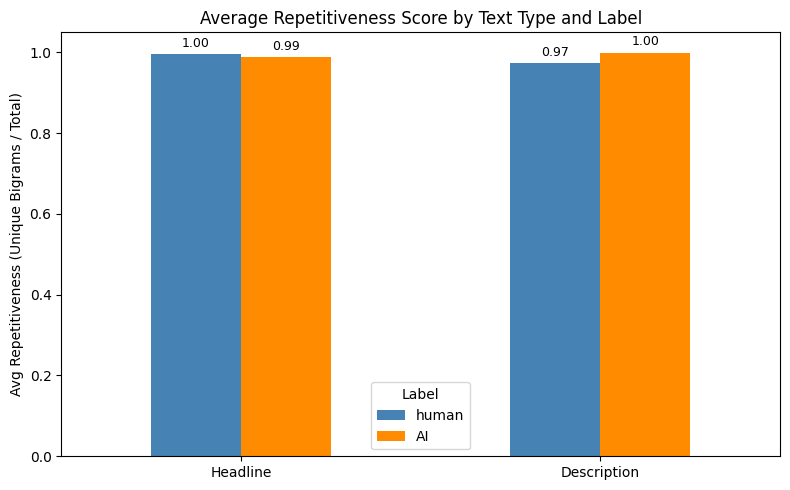

In [ ]:
#repetitiveness score

def calculate_repetitiveness_from_clean(text, n=2):
    tokens = text.split()
    grams = list(ngrams(tokens, n))
    if not grams:
        return 0.0
    unique = len(set(grams))
    total = len(grams)
    return unique / total

#apply to data
head_rep = political_2017['headline_clean'].apply(calculate_repetitiveness_from_clean)
desc_rep = political_2017['description_clean'].apply(calculate_repetitiveness_from_clean)

#combine
rep_df = pd.DataFrame({
    'label': political_2017['label'],
    'head_rep_score': head_rep,
    'desc_rep_score': desc_rep
})

#group
rep_scores = rep_df.groupby('label')[['head_rep_score', 'desc_rep_score']].mean().T

#plot

ax = rep_scores.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'darkorange'])
plt.title("Average Repetitiveness Score by Text Type and Label")
plt.ylabel("Avg Repetitiveness (Unique Bigrams / Total)")
plt.xticks(ticks=[0,1], labels=["Headline", "Description"], rotation=0)
plt.legend(title="Label", labels=["human", "AI"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", fontsize=9, padding=3)

plt.tight_layout()
plt.savefig("Average Repetitiveness Score by Text Type and Label.jpg", dpi=300)
plt.show()


##2.4 Sentiment Analysis

###2.4.1 Vader Sentiment

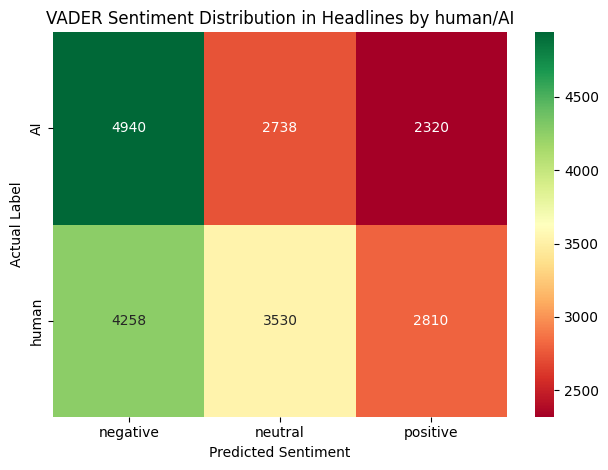

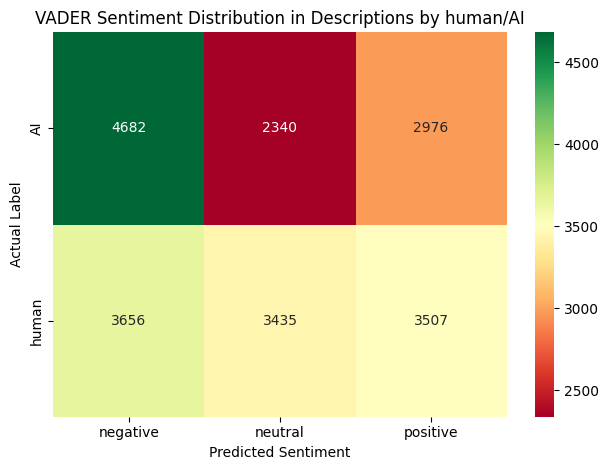

In [ ]:
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    return analyzer.polarity_scores(text)['compound']

#apply sentiment scores
headline_sent = political_2017[['headline', 'label']].copy()
headline_sent['compound'] = political_2017['headline'].apply(get_vader_sentiment)

desc_sent = political_2017[['short_description', 'label']].copy()
desc_sent['compound'] = political_2017['short_description'].apply(get_vader_sentiment)

#add label column
headline_sent['label'] = political_2017['label']
desc_sent['label'] = political_2017['label']

#group and get average sentiment
headline_avg = headline_sent.groupby('label')['compound'].mean()
desc_avg = desc_sent.groupby('label')['compound'].mean()

#add labels for sentiment classes
def compound_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

headline_sent['sentiment'] = headline_sent['compound'].apply(compound_to_label)
desc_sent['sentiment'] = desc_sent['compound'].apply(compound_to_label)

#map 0/1 labels to human/AI
headline_sent['label'] = headline_sent['label'].map({0: 'human', 1: 'AI'})
desc_sent['label'] = desc_sent['label'].map({0: 'human', 1: 'AI'})

#plot
def plot_sentiment_heatmap(df, label_name):
    df['sentiment'] = pd.Categorical(df['sentiment'], categories=['negative', 'neutral', 'positive'], ordered=True)
    cm = pd.crosstab(df['label'], df['sentiment'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
    plt.title(f"VADER Sentiment Distribution in {label_name.title()} by human/AI")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.savefig(f"VADER Sentiment Distribution in {label_name.title()} by human_AI.jpg", dpi=300)
    plt.show()

plot_sentiment_heatmap(headline_sent, "headlines")
plot_sentiment_heatmap(desc_sent, "descriptions")

###2.4.2 Text Blob Sentiment

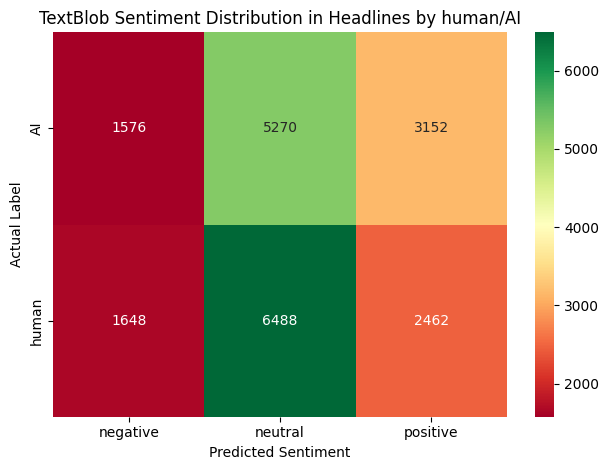

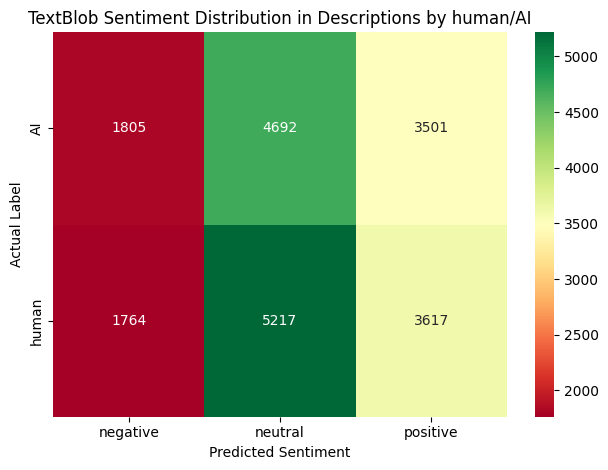

In [ ]:
#text blob

def get_textblob_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return TextBlob(text).sentiment.polarity

#apply to headline and description
headline_tb = political_2017['headline'].apply(get_textblob_sentiment)
desc_tb = political_2017['short_description'].apply(get_textblob_sentiment)

#convert polarity score to sentiment label
def polarity_to_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

#create DataFrames with sentiment labels and human/AI labels
headline_tb_df = pd.DataFrame({
    'label': political_2017['label'].map({0: 'human', 1: 'AI'}),
    'sentiment': headline_tb.apply(polarity_to_label)})

desc_tb_df = pd.DataFrame({
    'label': political_2017['label'].map({0: 'human', 1: 'AI'}),
    'sentiment': desc_tb.apply(polarity_to_label)})

#plot
def plot_sentiment_heatmap(df, label_name):
    cm = pd.crosstab(df['label'], df['sentiment'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
    plt.title(f"TextBlob Sentiment Distribution in {label_name.title()} by human/AI")
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.savefig(f"TextBlob Sentiment Distribution in {label_name.title()} by human_AI.jpg", dpi=300)
    plt.show()

plot_sentiment_heatmap(headline_tb_df, "headlines")
plot_sentiment_heatmap(desc_tb_df, "descriptions")

## 2.5 Topic modeling


###2.5.1 LDA

In [ ]:
#LDA

#split data into AI and human
human_headlines = political_2017[political_2017['label'] == 0]['headline_clean']
AI_headlines = political_2017[political_2017['label'] == 1]['headline_clean']
human_desc = political_2017[political_2017['label'] == 0]['description_clean']
AI_desc = political_2017[political_2017['label'] == 1]['description_clean']

#tokenize headlines
human_head_tokens = human_headlines.apply(lambda x: x.split()).tolist()
AI_head_tokens = AI_headlines.apply(lambda x: x.split()).tolist()
human_desc_tokens = human_desc.apply(lambda x: x.split()).tolist()
AI_desc_tokens = AI_desc.apply(lambda x: x.split()).tolist()

#create dictionary and corpus for headlines
human_head_dict = corpora.Dictionary(human_head_tokens)
human_head_bow = [human_head_dict.doc2bow(text) for text in human_head_tokens]

AI_head_dict = corpora.Dictionary(AI_head_tokens)
AI_head_bow = [AI_head_dict.doc2bow(text) for text in AI_head_tokens]

human_desc_dict = corpora.Dictionary(human_desc_tokens)
human_desc_bow = [human_desc_dict.doc2bow(text) for text in human_desc_tokens]

AI_desc_dict = corpora.Dictionary(AI_desc_tokens)
AI_desc_bow = [AI_desc_dict.doc2bow(text) for text in AI_desc_tokens]

#train LDA models for headlines and descriptions
lda_human_head = LdaMulticore(corpus=human_head_bow,
                             num_topics=10,
                             id2word=human_head_dict,
                             passes=2,
                             workers=2,
                             random_state=42)

lda_AI_head = LdaMulticore(corpus=AI_head_bow,
                             num_topics=10,
                             id2word=AI_head_dict,
                             passes=2,
                             workers=2,
                             random_state=42)
lda_human_desc = LdaMulticore(corpus=human_desc_bow,
                             num_topics=10,
                             id2word=human_desc_dict,
                             passes=2,
                             workers=2,
                             random_state=42)

lda_AI_desc = LdaMulticore(corpus=AI_desc_bow,
                             num_topics=10,
                             id2word=AI_desc_dict,
                             passes=2,
                             workers=2,
                             random_state=42)

#display topics for headlines and descriptions
def lda_topics_to_table(lda_model, num_words=8):
    topic_data = []
    for topic_id, topic in lda_model.show_topics(num_topics=-1, num_words=num_words, formatted=False):
        top_words = [word for word, _ in topic]
        topic_data.append({
            "Topic #": topic_id,
            "Top Words": ", ".join(top_words)
        })
    return pd.DataFrame(topic_data)


print("Topics in human Headlines")
display(lda_topics_to_table(lda_human_head))

print("Topics in AI Headlines")
display(lda_topics_to_table(lda_AI_head))

print("Topics in human Descriptions")
display(lda_topics_to_table(lda_human_desc))

print("Topics in AI Descriptions")
display(lda_topics_to_table(lda_AI_desc))


Topics in human Headlines


,Topic #,Top Words
0,0,"trump, obamacare, repeal, ban, huffpost, repub..."
1,1,"trump, day, president, donald, morning, email,..."
2,2,"trump, donald, republicans, gop, tax, care, ne..."
3,3,"trump, donald, court, health, care, gop, supre..."
4,4,"trump, donald, president, say, ban, tax, white..."
5,5,"trump, gop, donald, house, sessions, jeff, con..."
6,6,"trump, donald, house, white, say, ban, democra..."
7,7,"trump, email, morning, white, care, health, go..."
8,8,"trump, gop, care, donald, russia, health, say,..."
9,9,"trump, donald, house, russia, gop, john, new, ..."


Topics in AI Headlines


,Topic #,Top Words
0,0,"trump, say, border, election, fake, news, bill..."
1,1,"trump, plan, say, call, house, democrats, unve..."
2,2,"trump, impeachment, call, new, say, amid, demo..."
3,3,"trump, cdc, new, white, house, pardons, covid,..."
4,4,"trump, biden, say, call, handling, court, impe..."
5,5,"trump, call, say, new, news, probe, fake, tax"
6,6,"trump, plan, tax, new, call, pardons, gop, say"
7,7,"trump, new, house, say, face, impeachment, vot..."
8,8,"trump, impeachment, legal, trial, team, prepar..."
9,9,"trump, new, americans, legal, china, call, hou..."


Topics in human Descriptions


,Topic #,Top Words
0,0,"trump, country, senate, say, new, question, st..."
1,1,"trump, president, news, state, political, read..."
2,2,"trump, president, call, donald, new, bill, tim..."
3,3,"trump, president, say, white, people, new, don..."
4,4,"president, trump, say, donald, house, people, ..."
5,5,"say, trump, go, think, justice, new, departmen..."
6,6,"trump, house, gop, white, senate, care, health..."
7,7,"trump, people, say, like, president, america, ..."
8,8,"trump, president, state, say, people, look, wa..."
9,9,"say, want, trump, president, white, house, wee..."


Topics in AI Descriptions


,Topic #,Top Words
0,0,"president, trump, say, new, claim, donald, pla..."
1,1,"president, new, house, come, trump, americans,..."
2,2,"president, trump, spark, democrats, new, house..."
3,3,"president, come, spark, house, trump, say, whi..."
4,4,"come, president, new, plan, trump, say, year, ..."
5,5,"president, trump, say, come, administration, p..."
6,6,"president, trump, say, call, accuse, house, im..."
7,7,"president, trump, tax, plan, say, face, come, ..."
8,8,"trump, plan, president, tax, new, legal, wealt..."
9,9,"president, trump, face, come, campaign, lawyer..."


In [ ]:
#visualize human headline topics
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(lda_human_head, human_head_bow, human_head_dict)
pyLDAvis.enable_notebook()
pyLDAvis.display(vis)


In [ ]:
#visualize lda AI headlines
vis = pyLDAvis.gensim_models.prepare(lda_AI_head, AI_head_bow, AI_head_dict)
plt.savefig("AI_head_lda.jpg", dpi=300)
pyLDAvis.enable_notebook()
pyLDAvis.display(vis)

<Figure size 640x480 with 0 Axes>

In [ ]:
#visualize lda human short descriptions
vis = pyLDAvis.gensim_models.prepare(lda_human_desc, human_desc_bow, human_desc_dict)
plt.savefig("human_desc_lda.jpg", dpi=300)
pyLDAvis.enable_notebook()
pyLDAvis.display(vis)

<Figure size 640x480 with 0 Axes>

In [ ]:
#visualize lda AI short descriptions
vis = pyLDAvis.gensim_models.prepare(lda_AI_desc, AI_desc_bow, AI_desc_dict)
plt.savefig("AI_desc_lda.jpg", dpi=300)
pyLDAvis.enable_notebook()
pyLDAvis.display(vis)

<Figure size 640x480 with 0 Axes>

## 2.6 Final Dataset

In [ ]:
#quantifying insights from structural analysis

#collect top openers from all 4 lists
top_openers = set(
    [phrase for phrase, _ in human_headline_openers + AI_headline_openers + human_desc_openers + AI_desc_openers])

#extract first sentence opener from text
def get_first_opener(text):
    openers = extract_sentence_openers_from_clean(text, n_words=2)
    return openers[0] if openers else "<none>"

#apply to each row to get opener labels (as Series)
headline_openers = political_2017['headline_clean'].fillna('').apply(get_first_opener)
desc_openers = political_2017['description_clean'].fillna('').apply(get_first_opener)

#filter only known top openers; else label as <other>
def filter_known_opener(opener):
    return opener if opener in top_openers else "<other>"

headline_openers = headline_openers.apply(filter_known_opener)
desc_openers = desc_openers.apply(filter_known_opener)

#One-hot encode
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(pd.DataFrame({
    'headline_opener': headline_openers,
    'desc_opener': desc_openers}))

#output DataFrame
encoded_opener_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['headline_opener', 'desc_opener']),
    index=political_2017.index)

In [ ]:
#convert topic distributions to fixed-length vectors for classification

def topic_dicts_to_df(topic_dicts, num_topics, label):
    df = pd.DataFrame([
        [topic.get(i, 0.0) for i in range(num_topics)]
        for topic in topic_dicts
    ], columns=[f"topic_{i}" for i in range(num_topics)])
    df["label"] = label
    return df

#extract topic distributions (10 topics assumed)
NUM_TOPICS = 10

#HEADLINES
human_head_topic_features = [
    dict(lda_human_head.get_document_topics(bow, minimum_probability=0))
    for bow in human_head_bow]
AI_head_topic_features = [
    dict(lda_AI_head.get_document_topics(bow, minimum_probability=0))
    for bow in AI_head_bow]

#SHORT DESCRIPTIONS
human_desc_topic_features = [
    dict(lda_human_desc.get_document_topics(bow, minimum_probability=0))
    for bow in human_desc_bow]
AI_desc_topic_features = [
    dict(lda_AI_desc.get_document_topics(bow, minimum_probability=0))
    for bow in AI_desc_bow]

#convert to DataFrames with labels
human_head_topic_df = topic_dicts_to_df(human_head_topic_features, NUM_TOPICS, label=0)
AI_head_topic_df = topic_dicts_to_df(AI_head_topic_features, NUM_TOPICS, label=1)

human_desc_topic_df = topic_dicts_to_df(human_desc_topic_features, NUM_TOPICS, label=0)
AI_desc_topic_df = topic_dicts_to_df(AI_desc_topic_features, NUM_TOPICS, label=1)

#combine headline and description
head_topic_df = pd.concat([human_head_topic_df, AI_head_topic_df], ignore_index=True)
desc_topic_df = pd.concat([human_desc_topic_df, AI_desc_topic_df], ignore_index=True)

#rename
head_topic_df = head_topic_df.rename(columns={f"topic_{i}": f"head_topic_{i}" for i in range(NUM_TOPICS)})
desc_topic_df = desc_topic_df.rename(columns={f"topic_{i}": f"desc_topic_{i}" for i in range(NUM_TOPICS)})

#drop label columns so we don't duplicate them
X_topic = pd.concat([
    head_topic_df.drop(columns='label').reset_index(drop=True),
    desc_topic_df.drop(columns='label').reset_index(drop=True)
], axis=1)

#use label from either (they match)
y_topic = head_topic_df['label']

topic_df = pd.concat([head_topic_df.reset_index(drop=True), desc_topic_df.reset_index(drop=True)], axis=1)

In [ ]:
#from the analysis identified important features
pos_tags = ['NOUN', 'VERB','ADV']
ner_labels = ['PERSON', 'ORG']
selected_chars = ['char_quote', 'char_hyphen', 'char_colon', 'char_comma']
selected_conj = ['as', 'after', 'that']

features = []

for i, row in political_2017.iterrows():
    feats = {}

    feats['label'] = row['label']

    doc_head = row['headline_processed']
    doc_desc = row['description_processed']
    txt_head = row['headline']
    txt_desc = row['short_description']

    #POS counts

    def get_pos_counts(doc, pos_tags):
      return {
        tag: sum(1 for token in doc if token.pos_ == tag and token.is_alpha)
        for tag in pos_tags
    }

    head_pos = get_pos_counts(doc_head, pos_tags)
    desc_pos = get_pos_counts(doc_desc, pos_tags)
    head_len = len(txt_head.split()) if isinstance(txt_head, str) else 1
    desc_len = len(txt_desc.split()) if isinstance(txt_desc, str) else 1

    for tag in pos_tags:
        feats[f'head_POS_{tag}'] = head_pos.get(tag, 0)
        feats[f'desc_POS_{tag}'] = desc_pos.get(tag, 0)

    #NER counts
    def get_ner_counts(doc, ner_labels):
      return {
          label: sum(1 for ent in doc.ents if ent.label_ == label)
          for label in ner_labels
      }

    head_ner = get_ner_counts(doc_head, ner_labels)
    desc_ner = get_ner_counts(doc_desc, ner_labels)
    for label in ner_labels:
        feats[f'head_NER_{label}'] = head_ner.get(label, 0)
        feats[f'desc_NER_{label}'] = desc_ner.get(label, 0)

    #function/content ratios
    head_ratios = get_function_content_ratios(doc_head)
    desc_ratios = get_function_content_ratios(doc_desc)
    feats['head_func_ratio'] = head_ratios['function_ratio']
    feats['head_cont_ratio'] = head_ratios['content_ratio']
    feats['desc_func_ratio'] = desc_ratios['function_ratio']
    feats['desc_cont_ratio'] = desc_ratios['content_ratio']

    #VADER Sentiment
    feats['head_sentiment'] = get_vader_sentiment(txt_head)
    feats['desc_sentiment'] = get_vader_sentiment(txt_desc)

    #length
    feats['head_len'] = head_len
    feats['desc_len'] = desc_len

    #special characters
    def get_special_char_features(text):
      return {
          'char_exclam': text.count('!'),
          'char_hyphen': text.count('-'),
          'char_colon': text.count(':'),
          'char_quote': text.count('"'),
          'char_ellipsis': text.count('…'),
          'char_hashtag': text.count('#'),
          'char_at': text.count('@')
      }
    head_chars = get_special_char_features(txt_head)
    desc_chars = get_special_char_features(txt_desc)

    feats.update({f'head_{k}': head_chars[k] for k in selected_chars if k in head_chars})
    feats.update({f'desc_{k}': desc_chars[k] for k in selected_chars if k in desc_chars})

    #conjunctions
    def get_conjunction_counts(doc, keep=None):
      conjunctions = [
          'and', 'but', 'if', 'or', 'because', 'so', 'after', 'before',
          'when', 'while', 'although', 'though', 'since', 'until', 'as',
          'that', 'for', 'whether'
      ]
      counts = Counter(token.text.lower() for token in doc if token.text.lower() in conjunctions)

      if keep:
          counts = {f'conj_{k}': counts.get(k, 0) for k in keep}
      else:
          counts = {f'conj_{k}': v for k, v in counts.items()}

      return counts

    feats.update({f'head_{k}': v for k, v in get_conjunction_counts(doc_head, keep=selected_conj).items()})
    feats.update({f'desc_{k}': v for k, v in get_conjunction_counts(doc_desc, keep=selected_conj).items()})

    features.append(feats)

#final feature DataFrame
features_df = pd.DataFrame(features)

#make sure there are no dublicated columns
encoded_opener_df = encoded_opener_df.drop(columns=[col for col in encoded_opener_df.columns if col == 'label'], errors='ignore')
topic_df = topic_df.drop(columns=[col for col in topic_df.columns if col == 'label'], errors='ignore')

#merge
features_df = pd.concat([features_df.reset_index(drop=True), encoded_opener_df], axis=1)
features_df = pd.concat([features_df.reset_index(drop=True), topic_df.reset_index(drop=True)], axis=1)

#fill any nan with 0 for the classification (as it is looking at counts and ratios)
features_df.fillna(0, inplace=True)

#column labels
head_cols = [col for col in features_df.columns if col.startswith('head_')]
desc_cols = [col for col in features_df.columns if col.startswith('desc_')]

#keep the label
label_col = ['label']

#different dataset
features_both = features_df
features_desc_only = features_df[label_col + desc_cols]
features_head_only = features_df[label_col + head_cols]


In [ ]:
features_df.head()

,label,head_POS_NOUN,desc_POS_NOUN,head_POS_VERB,desc_POS_VERB,head_POS_ADV,desc_POS_ADV,head_NER_PERSON,desc_NER_PERSON,head_NER_ORG,...,desc_topic_0,desc_topic_1,desc_topic_2,desc_topic_3,desc_topic_4,desc_topic_5,desc_topic_6,desc_topic_7,desc_topic_8,desc_topic_9
0,0.0,1.0,4.0,1.0,3.0,0.0,1.0,0.0,1.0,0.0,...,0.008342,0.443810,0.008340,0.365858,0.008340,0.008341,0.008341,0.008340,0.008342,0.131946
1,0.0,3.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.016677,0.016677,0.016678,0.016676,0.849908,0.016675,0.016681,0.016674,0.016676,0.016676
2,1.0,3.0,4.0,3.0,2.0,1.0,1.0,0.0,0.0,1.0,...,0.409308,0.008343,0.523941,0.008344,0.008344,0.008344,0.008344,0.008344,0.008344,0.008343
3,0.0,0.0,3.0,2.0,3.0,0.0,0.0,0.0,0.0,1.0,...,0.007696,0.816456,0.007695,0.007695,0.007696,0.007696,0.007695,0.007696,0.121978,0.007697
4,1.0,0.0,3.0,2.0,2.0,0.0,1.0,0.0,0.0,1.0,...,0.016674,0.016674,0.016677,0.016673,0.016676,0.016673,0.016678,0.849926,0.016674,0.016676


# 3 Classification Modelling

## 3.1 Multinominal Naive Bayes

Headline + Description
Confusion Matrix:
[[1626  497]
 [ 520 1480]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.77      0.76      2123
         1.0       0.75      0.74      0.74      2000

    accuracy                           0.75      4123
   macro avg       0.75      0.75      0.75      4123
weighted avg       0.75      0.75      0.75      4123



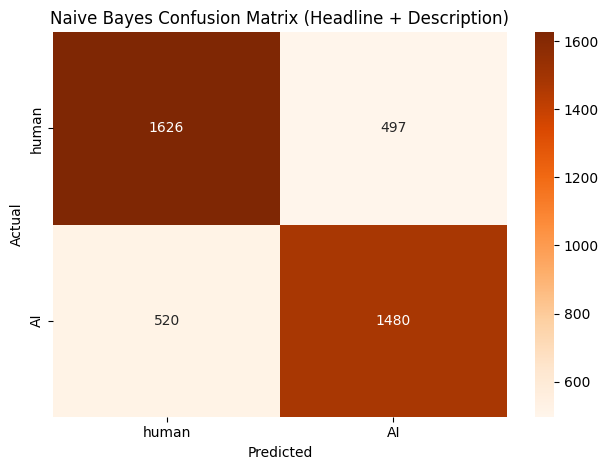

Headline Only
Confusion Matrix:
[[1520  603]
 [ 746 1254]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.67      0.72      0.69      2123
         1.0       0.68      0.63      0.65      2000

    accuracy                           0.67      4123
   macro avg       0.67      0.67      0.67      4123
weighted avg       0.67      0.67      0.67      4123



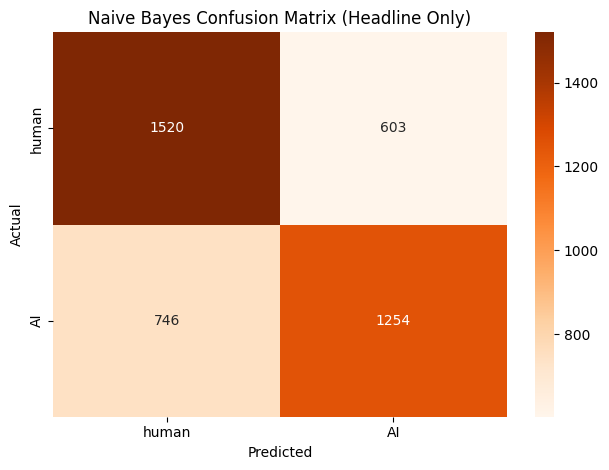

Description Only
Confusion Matrix:
[[1488  635]
 [ 569 1431]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.72      0.70      0.71      2123
         1.0       0.69      0.72      0.70      2000

    accuracy                           0.71      4123
   macro avg       0.71      0.71      0.71      4123
weighted avg       0.71      0.71      0.71      4123



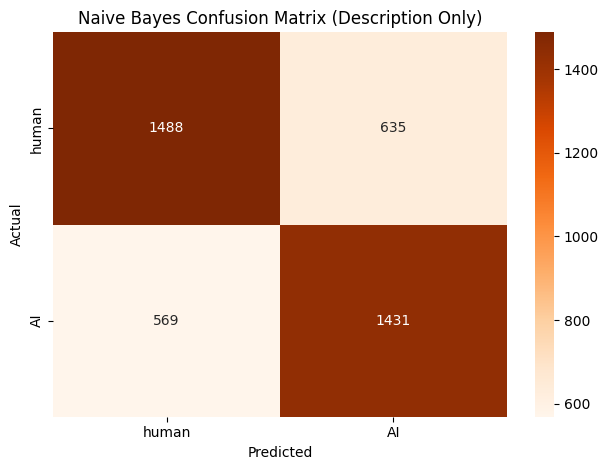

In [ ]:
#Multinominal naive bayes

#define which columns need scaling
def get_scalable_columns(df):
    return [col for col in df.columns
            if any(key in col for key in ['_ratio', 'topic_', 'sentiment'])
            and col != 'label']

#apply MinMax scaling and rounding
def scale_features(df):
    df_scaled = df.copy()
    cols_to_scale = get_scalable_columns(df_scaled)

    if cols_to_scale:
        scaler = MinMaxScaler((0, 10))
        df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])
        df_scaled[cols_to_scale] = df_scaled[cols_to_scale].round().astype(int)

    return df_scaled

#apply to all datasets
features_both_scaled = scale_features(features_both)
features_head_only_scaled = scale_features(features_head_only)
features_desc_only_scaled = scale_features(features_desc_only)

#naive Bayes training function
def run_naive_bayes(X, y, title_suffix=""):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    y_pred = nb.predict(X_test)

    print(f"{title_suffix}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Oranges',
                xticklabels=['human', 'AI'], yticklabels=['human', 'AI'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Naive Bayes Confusion Matrix ({title_suffix})")
    plt.tight_layout()
    plt.savefig(f"Naive Bayes Confusion Matrix ({title_suffix}).jpg", dpi=300)
    plt.show()

#run scaled models
run_naive_bayes(features_both_scaled.drop(columns='label'), features_both_scaled['label'], "Headline + Description")
run_naive_bayes(features_head_only_scaled.drop(columns='label'), features_head_only_scaled['label'], "Headline Only")
run_naive_bayes(features_desc_only_scaled.drop(columns='label'), features_desc_only_scaled['label'], "Description Only")



## 3.2 Logistic regression

Logistic Regression (Headline + Description)
Confusion Matrix:
[[1665  458]
 [ 469 1531]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.78      0.78      2123
         1.0       0.77      0.77      0.77      2000

    accuracy                           0.78      4123
   macro avg       0.77      0.77      0.77      4123
weighted avg       0.78      0.78      0.78      4123



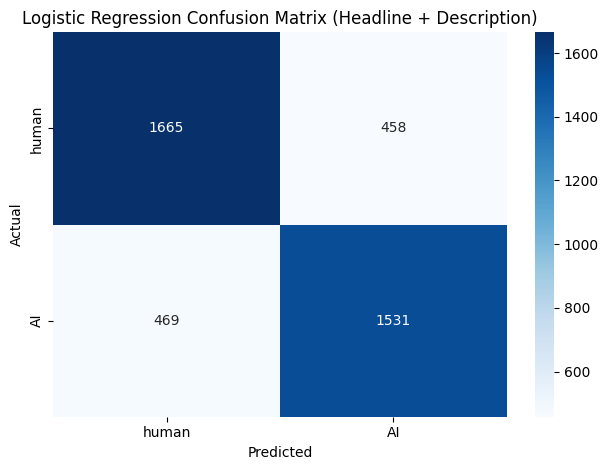

Logistic Regression (Headline Only)
Confusion Matrix:
[[1548  575]
 [ 661 1339]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.73      0.71      2123
         1.0       0.70      0.67      0.68      2000

    accuracy                           0.70      4123
   macro avg       0.70      0.70      0.70      4123
weighted avg       0.70      0.70      0.70      4123



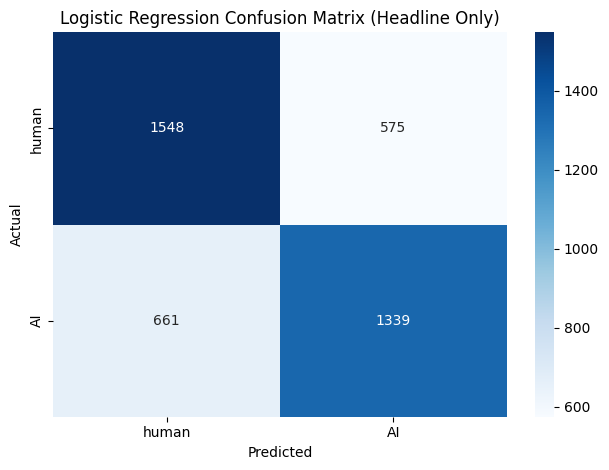

Logistic Regression (Description Only)
Confusion Matrix:
[[1526  597]
 [ 556 1444]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.73      0.72      0.73      2123
         1.0       0.71      0.72      0.71      2000

    accuracy                           0.72      4123
   macro avg       0.72      0.72      0.72      4123
weighted avg       0.72      0.72      0.72      4123



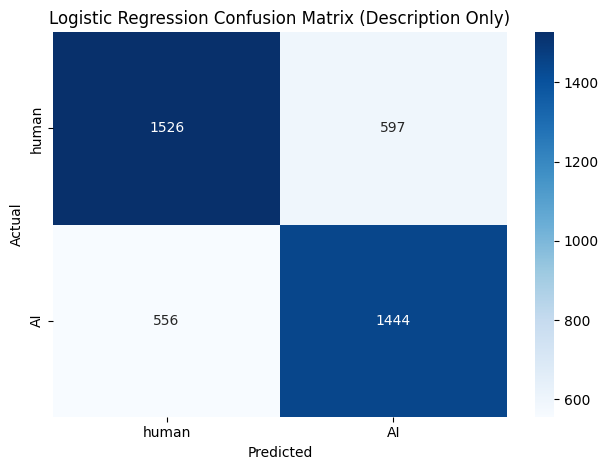

In [ ]:
#logistic regression

def run_logistic_regression(X, y, title_suffix=""):
    #split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    #scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    #train
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train_scaled, y_train)

    #predict
    y_pred = clf.predict(X_test_scaled)

    #evaluation
    print(f"Logistic Regression ({title_suffix})")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
                xticklabels=['human', 'AI'], yticklabels=['human', 'AI'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Logistic Regression Confusion Matrix ({title_suffix})")
    plt.tight_layout()
    plt.savefig(f"Logistic Regression Confusion Matrix ({title_suffix}).jpg", dpi=300)
    plt.show()

# Run on all three datasets
run_logistic_regression(features_both.drop(columns='label'), features_both['label'], "Headline + Description")
run_logistic_regression(features_head_only.drop(columns='label'), features_head_only['label'], "Headline Only")
run_logistic_regression(features_desc_only.drop(columns='label'), features_desc_only['label'], "Description Only")



## 3.3 BERT Model

In [ ]:
!pip install --upgrade pip
!pip uninstall -y numpy transformers datasets peft
!pip install numpy==1.26.4 transformers==4.40.1 datasets==2.18.0 peft==0.10.0 scipy==1.13.0

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: transformers 4.40.1
Uninstalling transformers-4.40.1:
  Successfully uninstalled transformers-4.40.1
Found existing installation: datasets 2.18.0
Uninstalling datasets-2.18.0:
  Successfully uninstalled datasets-2.18.0
Found existing installation: peft 0.10.0
Uninstalling peft-0.10.0:
  Successfully uninstalled peft-0.10.0
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached transformers-4.40.1-py3-none-any.whl.metadata (137 kB)
  Using cached datasets-2.18.0-py3-none-any.whl.metadata (20 kB)
  Using cached peft-0.10.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
Using cached transformers-4.40.1-py3-none-any.whl (9.0 MB)
Using cached datasets-2.18.0-py3-none-any.whl (510 kB)
Using cached peft-0.10.0-py3

restart after this cell!! then rerun this cell and then import cells below

###3.3.1 Dataset preparation

In [ ]:
#load and check for NA
text = pd.read_csv('political_2017')
text.isna().sum()
text = text.dropna()

In [ ]:
#create subset with only important columns
text = text[['headline','short_description', 'label']]
text.head()

,headline,short_description,label
0,Pennsylvania Governor: Women Can 'Make Their O...,Gov. Tom Wolf plans to veto a highly restricti...,0
1,Trump’s Outsourcing Of War Decision-Making Wor...,But Republicans say they're OK with the Pentag...,0
2,"Trump's 2024 Campaign Slogan Revealed: ""Make A...",The slogan has already sparked a mix of reacti...,1
3,Trump To Nominate Huntsman As Russia Ambassado...,"If confirmed, Huntsman will head to Moscow as ...",0
4,"Trump's Popularity Surges Post-Impeachment, Po...",The latest survey from the Pew Research Center...,1


In [ ]:
#simple BERT cleaning function to apply on raw text

def bert_preprocess(text):
    text = text.strip()
    text = " ".join(text.split())

    return text

#apply
text['headline_clean'] = text['headline'].apply(bert_preprocess)
text['description_clean'] = text['short_description'].apply(bert_preprocess)
text.head()

In [ ]:
bert_text = text[['headline_clean', 'description_clean', 'label']]
bert_text.head()

,headline_clean,description_clean,label
0,Pennsylvania Governor: Women Can 'Make Their O...,Gov. Tom Wolf plans to veto a highly restricti...,0
1,Trump’s Outsourcing Of War Decision-Making Wor...,But Republicans say they're OK with the Pentag...,0
2,"Trump's 2024 Campaign Slogan Revealed: ""Make A...",The slogan has already sparked a mix of reacti...,1
3,Trump To Nominate Huntsman As Russia Ambassado...,"If confirmed, Huntsman will head to Moscow as ...",0
4,"Trump's Popularity Surges Post-Impeachment, Po...",The latest survey from the Pew Research Center...,1


### 3.3.2 BERT Model

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

#### 3.3.2.1 BERT Model - Combined

In [ ]:
#BERT tokenisation

def tokenize_function(example):
  return tokenizer(example['headline_clean'], example['description_clean'], truncation=True, max_length = 512)

dataset = Dataset.from_pandas(bert_text)

if '__index_level_0__' in dataset.column_names:
    dataset = dataset.remove_columns(['__index_level_0__'])

tokenized_dataset = dataset.map(tokenize_function, batched = True)

Map:   0%|          | 0/20513 [00:00<?, ? examples/s]

In [ ]:
#formatting of dataset for BERT
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset = tokenized_dataset.remove_columns(['headline_clean', 'description_clean'])

In [ ]:
tokenized_dataset.set_format("numpy")

In [ ]:
tokenized_dataset.set_format("torch")

In [ ]:
tokenized_dataset.features

{'labels': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}

In [ ]:
len(tokenized_dataset)

20513

In [ ]:
split_dataset = tokenized_dataset.train_test_split(test_size=0.2)
train_dataset = split_dataset['train']
test_dataset = split_dataset['test']

In [ ]:
#model initialisation
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    run_name="bert-ai-vs-human",
    save_strategy = 'epoch',
    learning_rate = 2e-5,
    num_train_epochs = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    weight_decay = 0.01,
    remove_unused_columns=False,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    data_collator=data_collator
    )

In [ ]:
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
#training
trainer.train()

Step,Training Loss
500,0.233400
1000,0.104400
1500,0.108500
2000,0.089000
2500,0.021700
3000,0.023400
3500,0.027600
4000,0.020400


Step,Training Loss
500,0.233400
1000,0.104400
1500,0.108500
2000,0.089000
2500,0.021700
3000,0.023400
3500,0.027600
4000,0.020400
4500,0.010800
5000,0.008200


TrainOutput(global_step=6156, training_loss=0.05308796303943429, metrics={'train_runtime': 738.1464, 'train_samples_per_second': 66.694, 'train_steps_per_second': 8.34, 'total_flos': 1188829275874440.0, 'train_loss': 0.05308796303943429, 'epoch': 3.0})

In [ ]:
#evalutaion
trainer.evaluate()

predictions = trainer.predict(test_dataset)

In [ ]:
predictions

In [ ]:
preds = np.argmax(predictions.predictions, axis=1)
true = predictions.label_ids

In [ ]:
print("Accuracy:", accuracy_score(true, preds))
print("Confusion Matrix:\n", confusion_matrix(true, preds))
print("Classification Report:\n", classification_report(true, preds, target_names=["Human", "AI"]))

Accuracy: 0.9868388983670485
Confusion Matrix:
 [[2035   50]
 [   4 2014]]
Classification Report:
               precision    recall  f1-score   support

       Human       1.00      0.98      0.99      2085
          AI       0.98      1.00      0.99      2018

    accuracy                           0.99      4103
   macro avg       0.99      0.99      0.99      4103
weighted avg       0.99      0.99      0.99      4103



#### 3.3.2.2 BERT Model - Headlines

In [ ]:
bert_headlines = text[['headline_clean', 'label']]
bert_headlines.head()

,headline_clean,label
0,Pennsylvania Governor: Women Can 'Make Their O...,0
1,Trump’s Outsourcing Of War Decision-Making Wor...,0
2,"Trump's 2024 Campaign Slogan Revealed: ""Make A...",1
3,Trump To Nominate Huntsman As Russia Ambassado...,0
4,"Trump's Popularity Surges Post-Impeachment, Po...",1


In [ ]:
#BERT tokenisation

def tokenize_function_headlines(example):
  return tokenizer(example['headline_clean'], truncation=True, max_length = 512)

dataset_headlines = Dataset.from_pandas(bert_headlines)

if '__index_level_0__' in dataset_headlines.column_names:
    dataset_headlines = dataset_headlines.remove_columns(['__index_level_0__'])

tokenized_dataset_headlines = dataset_headlines.map(tokenize_function_headlines, batched = True)

Map:   0%|          | 0/20513 [00:00<?, ? examples/s]

In [ ]:
# Formatting of dataset for BERT
tokenized_dataset_headlines = tokenized_dataset_headlines.remove_columns(['headline_clean'])

In [ ]:
tokenized_dataset_headlines.set_format("numpy")

In [ ]:
tokenized_dataset_headlines.set_format("torch")

In [ ]:
tokenized_dataset_headlines.features

{'labels': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}

In [ ]:
len(tokenized_dataset_headlines)

20513

In [ ]:
split_dataset_headlines = tokenized_dataset_headlines.train_test_split(test_size=0.2)
train_dataset = split_dataset['train']
test_dataset = split_dataset['test']

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    run_name="bert-ai-vs-human",
    save_strategy = 'epoch',
    learning_rate = 2e-5,
    num_train_epochs = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    weight_decay = 0.01,
    remove_unused_columns=False,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_headlines = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset_headlines,
    eval_dataset = test_dataset_headlines,
    data_collator=data_collator
    )

In [ ]:
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
#training
trainer_headlines.train()

Step,Training Loss
500,0.315300
1000,0.222400
1500,0.197800
2000,0.137600
2500,0.073300
3000,0.068200
3500,0.074700
4000,0.072400
4500,0.036500
5000,0.025600


TrainOutput(global_step=6156, training_loss=0.10284380927497958, metrics={'train_runtime': 282.0187, 'train_samples_per_second': 174.563, 'train_steps_per_second': 21.828, 'total_flos': 549734577960120.0, 'train_loss': 0.10284380927497958, 'epoch': 3.0})

In [ ]:
#evaluation
trainer_headlines.evaluate()

predictions_headlines = trainer_headlines.predict(test_dataset)

In [ ]:
predictions_headlines

PredictionOutput(predictions=array([[-4.9958935,  5.2685065],
       [ 2.4045448, -2.7176225],
       [-5.076861 ,  5.2954254],
       ...,
       [-5.1531267,  5.324358 ],
       [-5.20718  ,  5.395842 ],
       [-5.1721416,  5.331195 ]], dtype=float32), label_ids=array([1, 0, 1, ..., 1, 1, 1]), metrics={'test_loss': 0.058511652052402496, 'test_runtime': 7.3059, 'test_samples_per_second': 561.602, 'test_steps_per_second': 70.217})

In [ ]:
preds = np.argmax(predictions_headlines.predictions, axis=1)
true = predictions_headlines.label_ids

In [ ]:
print("Accuracy:", accuracy_score(true, preds))
print("Confusion Matrix:\n", confusion_matrix(true, preds))
print("Classification Report:\n", classification_report(true, preds, target_names=["Human", "AI"]))

Accuracy: 0.9814769680721424
Confusion Matrix:
 [[2040   58]
 [  18 1987]]
Classification Report:
               precision    recall  f1-score   support

       Human       0.99      0.97      0.98      2098
          AI       0.97      0.99      0.98      2005

    accuracy                           0.98      4103
   macro avg       0.98      0.98      0.98      4103
weighted avg       0.98      0.98      0.98      4103





#### 3.3.2.3 BERT Model - Descriptions

In [ ]:
bert_descriptions = text[['description_clean', 'label']]
bert_descriptions.head()

,description_clean,label
0,Gov. Tom Wolf plans to veto a highly restricti...,0
1,But Republicans say they're OK with the Pentag...,0
2,The slogan has already sparked a mix of reacti...,1
3,"If confirmed, Huntsman will head to Moscow as ...",0
4,The latest survey from the Pew Research Center...,1


In [ ]:
#BERT tokenisation
def tokenize_function_descriptions(example):
  return tokenizer(example['description_clean'], truncation=True, max_length = 512)

dataset_descriptions = Dataset.from_pandas(bert_descriptions)

if '__index_level_0__' in dataset_descriptions.column_names:
    dataset_descriptions = dataset_descriptions.remove_columns(['__index_level_0__'])

tokenized_dataset_descriptions = dataset_descriptions.map(tokenize_function_descriptions, batched = True)

Map:   0%|          | 0/20513 [00:00<?, ? examples/s]

In [ ]:
#formatting of dataset for BERT
tokenized_dataset_descriptions = tokenized_dataset_descriptions.remove_columns(['description_clean'])

In [ ]:
tokenized_dataset_descriptions.set_format("numpy")

In [ ]:
tokenized_dataset_descriptions.set_format("torch")

In [ ]:
tokenized_dataset_descriptions.features

{'label': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}

In [ ]:
len(tokenized_dataset_descriptions)

20513

In [ ]:
split_dataset = tokenized_dataset_descriptions.train_test_split(test_size=0.2)
train_dataset = split_dataset['train']
test_dataset = split_dataset['test']

In [ ]:
training_args = TrainingArguments(
    output_dir = './results',
    run_name="bert-ai-vs-human",
    save_strategy = 'epoch',
    learning_rate = 2e-5,
    num_train_epochs = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    weight_decay = 0.01,
    remove_unused_columns=False,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer_descriptions = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset_descriptions,
    eval_dataset = test_dataset_descriptions,
    data_collator=data_collator
    )

In [ ]:
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
#training
trainer_descriptions.train()

Step,Training Loss
500,0.295900
1000,0.201800
1500,0.195900
2000,0.153900
2500,0.067900
3000,0.084100
3500,0.064400
4000,0.076700
4500,0.032200
5000,0.012700


TrainOutput(global_step=6156, training_loss=0.0997913501880787, metrics={'train_runtime': 284.188, 'train_samples_per_second': 173.23, 'train_steps_per_second': 21.662, 'total_flos': 786211805630280.0, 'train_loss': 0.0997913501880787, 'epoch': 3.0})

In [ ]:
#evaluation
trainer_descriptions.evaluate()

predictions_descriptions = trainer_descriptions.predict(test_dataset)

In [ ]:
predictions_descriptions

PredictionOutput(predictions=array([[-5.06895  ,  5.434149 ],
       [ 3.565747 , -4.071095 ],
       [-4.9480453,  5.300603 ],
       ...,
       [-5.026912 ,  5.308391 ],
       [-4.9732904,  5.294535 ],
       [-4.111782 ,  4.4912395]], dtype=float32), label_ids=array([1, 0, 1, ..., 1, 1, 1]), metrics={'test_loss': 0.18001677095890045, 'test_runtime': 7.318, 'test_samples_per_second': 560.671, 'test_steps_per_second': 70.101})

In [ ]:
preds = np.argmax(predictions_descriptions.predictions, axis=1)
true = predictions_descriptions.label_ids

In [ ]:
print("Accuracy:", accuracy_score(true, preds))
print("Confusion Matrix:\n", confusion_matrix(true, preds))
print("Classification Report:\n", classification_report(true, preds, target_names=["Human", "AI"]))

Accuracy: 0.964903728978796
Confusion Matrix:
 [[1965  133]
 [  11 1994]]
Classification Report:
               precision    recall  f1-score   support

       Human       0.99      0.94      0.96      2098
          AI       0.94      0.99      0.97      2005

    accuracy                           0.96      4103
   macro avg       0.97      0.97      0.96      4103
weighted avg       0.97      0.96      0.96      4103



#### 3.3.2.5 Evalutation Dataset

In [ ]:
#human news dataset
human_news = pd.read_csv('human_News.csv')
human_news.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


In [ ]:
human_news['date'] = pd.to_datetime(human_news['date'], errors='coerce', format='mixed')
human_news['year'] = human_news['date'].dt.year

In [ ]:
human_news_ent = human_news[(human_news['category'] == 'ENTERTAINMENT') & (human_news['year']==2017)][['headline', 'short_description']]
human_news_ent['label'] = 0
human_news_ent.head()

,headline,short_description,label
17266,Catelynn Lowell Of 'Teen Mom OG' Heads Home Af...,"""So excited for the future,"" tweets Nova's mot...",0
17275,Chelsea Clinton Gives Chrissy Teigen Powerful ...,Clinton stepped in after Teigen's 1-year-old d...,0
17277,That 'Last Jedi' Reveal About Rey's Parents Is...,Director Rian Johnson gives us a Rey of hope.,0
17285,"Annette Bening On Disco Dancing, Loving Greta ...","In her new movie ""Film Stars Don't Die in Live...",0
17306,Lindsay Lohan Shows Off The Snakebite She Got ...,"""My shaman told me it was good luck and positi...",0


In [ ]:
human_news_ent.shape

(3190, 3)

In [ ]:
#randomly select 1000 rows from human_news_ent
human_news_ent = human_news_ent.sample(n=1000, random_state=42)
human_news_ent.shape

(1000, 3)

In [ ]:
#AI news
ai_news_ent = pd.read_csv('llama_huffpost_dataset_entertainment.csv')
ai_news_ent.head(10)

,headline,description
0,Miley Cyrus Takes Over the Music Industry,"Pop star's latest album debuts at number one, ..."
1,The Handmaid's Tale: Hulu Drops First Trailer,Hulu has released the first trailer for
2,Netflix's New Original Series a Hit,Netflix's latest original series has taken the...
3,"""MTV Announces New Reality Show: 'The Challeng...","""Singer Katy Perry is set to release her highl..."
4,The One Direction Hiatus: What It Means For Fans,The announcement of the One Direction hiatus h...
5,"Beyonce Releases New Single, Fans Go Wild","Beyonce has released a brand new single, and f..."
6,"""MTV Announces New Reality Show: 'The Singing ...",MTV is set to premiere a brand new reality sho...
7,Jennifer Lawrence Talks New Movie Role,Actress Jennifer Lawrence recently sat down wi...
8,Game of Thrones Sneak Peek: The Battle for,Jennifer Lawrence has come forward with her pe...
9,Meryl Streep to Star in Net,"The pop star's latest track is a catchy, upbea..."


In [ ]:
#rename description column
ai_news_ent = ai_news_ent.rename(columns={'description': 'short_description'})
ai_news_ent.head()

,headline,short_description
0,Miley Cyrus Takes Over the Music Industry,"Pop star's latest album debuts at number one, ..."
1,The Handmaid's Tale: Hulu Drops First Trailer,Hulu has released the first trailer for
2,Netflix's New Original Series a Hit,Netflix's latest original series has taken the...
3,"""MTV Announces New Reality Show: 'The Challeng...","""Singer Katy Perry is set to release her highl..."
4,The One Direction Hiatus: What It Means For Fans,The announcement of the One Direction hiatus h...


In [ ]:
ai_news_ent['label'] = 1
ai_news_ent.head()

,headline,short_description,label
0,Miley Cyrus Takes Over the Music Industry,"Pop star's latest album debuts at number one, ...",1
1,The Handmaid's Tale: Hulu Drops First Trailer,Hulu has released the first trailer for,1
2,Netflix's New Original Series a Hit,Netflix's latest original series has taken the...,1
3,"""MTV Announces New Reality Show: 'The Challeng...","""Singer Katy Perry is set to release her highl...",1
4,The One Direction Hiatus: What It Means For Fans,The announcement of the One Direction hiatus h...,1


In [ ]:
#evaluation dataset
eval_text = pd.concat([human_news_ent, ai_news_ent], ignore_index=True)
eval_text

,headline,short_description,label
0,"Pharrell, Ariana Grande And The Dave Matthews ...","An “evening of music and unity"" will benefit v...",0
1,Emmy Winner Leah Remini Jokingly Forgives Mom ...,"Without that experience, she wouldn’t have mad...",0
2,We Finally Know Why The Scavengers Speak So St...,Executive Producer David Alpert clears things up.,0
3,'The Mindy Project' Went Out Exactly The Way M...,“The Mindy Project” wraps up six seasons of Mi...,0
4,'Heathers' TV Show Teaser Drops To Remind Us W...,It's about time that clique came back.,0
...,...,...,...
1922,Star Wars: The Last Jedi - Everything You Need...,The highly anticipated Star Wars: The Last Jed...,1
1923,"Beyoncé Opens Up About Marriage, Motherhood, a...","In a rare interview, Queen Bey shares her thou...",1
1924,Beyoncé's Latest Video Sparks Controversy,Beyoncé's latest music video has sparked contr...,1
1925,Taylor Swift Slams New York Times Over Coverage,Taylor Swift has taken to social media to slam...,1


In [ ]:
eval_text.isna().sum()
eval_text = eval_text.dropna(subset=['short_description'])

In [ ]:
eval_text['label'].value_counts()

,count
label,
0,996
1,927


In [ ]:
#BERT preprocessing of evaluation dataset
eval_text['headline_clean'] = eval_text['headline'].apply(bert_preprocess)
eval_text['description_clean'] = eval_text['short_description'].apply(bert_preprocess)
eval_text.head()

<ipython-input-82-47594dbbe020>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_text['headline_clean'] = eval_text['headline'].apply(bert_preprocess)
<ipython-input-82-47594dbbe020>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_text['description_clean'] = eval_text['short_description'].apply(bert_preprocess)


,headline,short_description,label,headline_clean,description_clean
0,"Pharrell, Ariana Grande And The Dave Matthews ...","An “evening of music and unity"" will benefit v...",0,"Pharrell, Ariana Grande And The Dave Matthews ...","An “evening of music and unity"" will benefit v..."
1,Emmy Winner Leah Remini Jokingly Forgives Mom ...,"Without that experience, she wouldn’t have mad...",0,Emmy Winner Leah Remini Jokingly Forgives Mom ...,"Without that experience, she wouldn’t have mad..."
2,We Finally Know Why The Scavengers Speak So St...,Executive Producer David Alpert clears things up.,0,We Finally Know Why The Scavengers Speak So St...,Executive Producer David Alpert clears things up.
3,'The Mindy Project' Went Out Exactly The Way M...,“The Mindy Project” wraps up six seasons of Mi...,0,'The Mindy Project' Went Out Exactly The Way M...,“The Mindy Project” wraps up six seasons of Mi...
4,'Heathers' TV Show Teaser Drops To Remind Us W...,It's about time that clique came back.,0,'Heathers' TV Show Teaser Drops To Remind Us W...,It's about time that clique came back.


In [ ]:
dataset_eval = Dataset.from_pandas(eval_text)

if '__index_level_0__' in dataset_eval.column_names:
    dataset_eval = dataset_eval.remove_columns(['__index_level_0__'])

tokenized_dataset_eval = dataset_eval.map(tokenize_function, batched = True)

Map:   0%|          | 0/1923 [00:00<?, ? examples/s]

In [ ]:
#formatting of dataset for BERT
tokenized_dataset_eval = tokenized_dataset_eval.rename_column('label', 'labels')
tokenized_dataset_eval = tokenized_dataset_eval.remove_columns(['headline_clean', 'description_clean', 'headline', 'short_description'])

In [ ]:
tokenized_dataset_eval.set_format("numpy")

In [ ]:
tokenized_dataset_eval.set_format("torch")

In [ ]:
tokenized_dataset_eval.features

{'labels': Value(dtype='int64', id=None),
 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None),
 'token_type_ids': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None),
 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}

In [ ]:
len(tokenized_dataset_eval)

1923

In [ ]:
#training
predictions_eval = trainer.predict(tokenized_dataset_eval)

In [ ]:
trainer.evaluate()

predictions = trainer.predict(test_dataset, data_collator=data_collator)

predictions

In [ ]:
preds_eval = np.argmax(predictions_eval.predictions, axis=1)
true_eval = predictions_eval.label_ids

In [ ]:
print("Accuracy:", accuracy_score(true_eval, preds_eval))
print("Confusion Matrix:\n", confusion_matrix(true_eval, preds_eval))
print("Classification Report:\n", classification_report(true_eval, preds_eval, target_names=["Human", "AI"]))

Accuracy: 0.8575143005720229
Confusion Matrix:
 [[982  14]
 [260 667]]
Classification Report:
               precision    recall  f1-score   support

       Human       0.79      0.99      0.88       996
          AI       0.98      0.72      0.83       927

    accuracy                           0.86      1923
   macro avg       0.89      0.85      0.85      1923
weighted avg       0.88      0.86      0.85      1923



In [ ]:
eval_text['predicted_label'] = preds_eval
eval_text.to_csv('bert_eval_results.csv', index = False)
eval_text.head()

<ipython-input-95-9f4df049efb0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eval_text['predicted_label'] = preds_eval


,headline,short_description,label,headline_clean,description_clean,predicted_label
0,"Pharrell, Ariana Grande And The Dave Matthews ...","An “evening of music and unity"" will benefit v...",0,"Pharrell, Ariana Grande And The Dave Matthews ...","An “evening of music and unity"" will benefit v...",0
1,Emmy Winner Leah Remini Jokingly Forgives Mom ...,"Without that experience, she wouldn’t have mad...",0,Emmy Winner Leah Remini Jokingly Forgives Mom ...,"Without that experience, she wouldn’t have mad...",0
2,We Finally Know Why The Scavengers Speak So St...,Executive Producer David Alpert clears things up.,0,We Finally Know Why The Scavengers Speak So St...,Executive Producer David Alpert clears things up.,0
3,'The Mindy Project' Went Out Exactly The Way M...,“The Mindy Project” wraps up six seasons of Mi...,0,'The Mindy Project' Went Out Exactly The Way M...,“The Mindy Project” wraps up six seasons of Mi...,0
4,'Heathers' TV Show Teaser Drops To Remind Us W...,It's about time that clique came back.,0,'Heathers' TV Show Teaser Drops To Remind Us W...,It's about time that clique came back.,0


In [ ]:
eval_text['predicted_label'].value_counts()

,count
predicted_label,
0,1242
1,681
